<a href="https://colab.research.google.com/github/sylkip3/Applied-ML_CourseWork-2/blob/main/CMP7239_RT_IoT2022_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CMP7239 Applied Machine Learning
## Predicting Network Flow Duration in IoT Environments Using Regression
### Dataset: RT-IoT2022 (Regression-Ready, 50 Features)

---

**Dataset:** `rt_iot2022_regression_ready_50_features.csv` — pre-selected feature subset of the full RT-IoT2022 dataset, containing 50 network flow features and the continuous regression target `flow_duration`. Attack_type label not included; this study focuses exclusively on the regression task.

**Target Variable:** `flow_duration` (continuous, seconds) — log1p-transformed for modelling

**Models Implemented:**
| # | Model | Family | Justification |
|---|-------|--------|---------------|
| 1 | Ridge Regression | Linear | Regularised baseline; reveals whether a linear relationship exists |
| 2 | Random Forest | Ensemble (Bagging) | Robust to outliers; handles mixed feature types; interpretable via MDI importance |
| 3 | XGBoost | Ensemble (Boosting) | State-of-the-art on tabular data; GPU-accelerated; L1/L2 regularisation built-in |
| 4 | SVR (RBF) | Kernel-based | Captures non-linear relationships via kernel trick; different inductive bias to trees |
| 5 | MLP | Deep Learning | Benchmarks neural network performance vs traditional ML on tabular IoT data |
| 6 | LSTM | Deep Learning (Recurrent) | Models temporal dependencies in feature sequences; captures flow behaviour patterns |
| 7 | Stacking Ensemble | Meta-Learning | Combines all 6 base models; learns which to trust per flow type via 5-fold OOF |


## 1. Environment Setup

In [1]:
!pip install -q xgboost shap ucimlrepo optuna scikit-learn joblib torch
# Note: PyTorch may already be available in Colab — the install above is a no-op if so.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import warnings, os, joblib, time
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.ticker import MaxNLocator

plt.rcParams.update({
    'figure.dpi': 120, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.labelsize': 11,
})
PALETTE = ['#2563EB', '#16A34A', '#D97706', '#DC2626', '#7C3AED']

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.inspection import permutation_importance

import xgboost as xgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── PyTorch (Deep Learning) ──────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import copy as copy_module

print('All libraries loaded successfully')
print(f'  XGBoost {xgb.__version__} | SHAP {shap.__version__} | Optuna {optuna.__version__} | PyTorch {torch.__version__}')


All libraries loaded successfully
  XGBoost 3.2.0 | SHAP 0.51.0 | Optuna 4.8.0 | PyTorch 2.10.0+cu128


## 2. Data Loading

In [3]:
## 2. Data Loading

print('Loading RT-IoT2022 regression-ready CSV...')
df = pd.read_csv('rt_iot2022_regression_ready_50_features.csv')

print(f'Shape          : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Memory         : {df.memory_usage(deep=True).sum()/1e6:.1f} MB')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Duplicate rows : {df.duplicated().sum():,}')
df.head(5)


Loading RT-IoT2022 regression-ready CSV...
Shape          : 123,117 rows x 51 columns
Memory         : 60.9 MB
Missing values : 0
Duplicate rows : 5,202


,id.orig_p,id.resp_p,proto,service,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,...,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,flow_duration
0,38667,1883,tcp,mqtt,9,5,3,3,0.281148,0.156193,...,7.714286,11.618477,761.985779,29729182.96,32011597.87,4001449.734,10403073.63,4438.877106,1511693.954,32.011598
1,51143,1883,tcp,mqtt,9,5,3,3,0.282277,0.156821,...,7.714286,11.618477,247.001648,29855277.06,31883584.02,3985448.003,10463455.56,4214.048386,1576435.804,31.883584
2,44761,1883,tcp,mqtt,9,5,3,3,0.280164,0.155647,...,7.428571,11.229866,283.956528,29842149.02,32124053.00,4015506.625,10442377.92,2456.903458,1476048.946,32.124053
3,60893,1883,tcp,mqtt,9,5,3,3,0.281593,0.156440,...,7.428571,11.229866,288.963318,29913774.97,31961063.15,3995132.893,10482528.22,3933.906555,1551892.042,31.961063
4,51087,1883,tcp,mqtt,9,5,3,3,0.282111,0.156728,...,7.714286,11.618477,387.907028,29814704.90,31902361.87,3987795.234,10447019.10,3005.027771,1632083.178,31.902362


In [4]:
TARGET    = 'flow_duration'
assert TARGET in df.columns, f'{TARGET} not found in columns'

# Attack_type is not present in the regression-ready CSV.
# This study focuses exclusively on the regression task (flow_duration).
# LABEL_COL is set to None — Sections 3.3 and 8 are skipped by design.
LABEL_COL = None

print(f'Target column : {TARGET}')
print(f'Label column  : {LABEL_COL}  (Attack_type excluded — regression-only dataset)')
print(f'\nFeature columns ({df.shape[1] - 1}):')
print([c for c in df.columns if c != TARGET])
df.head(3)


Target column : flow_duration
Label column  : None  (Attack_type excluded — regression-only dataset)

Feature columns (50):
['id.orig_p', 'id.resp_p', 'proto', 'service', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot'

,id.orig_p,id.resp_p,proto,service,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,...,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,flow_duration
0,38667,1883,tcp,mqtt,9,5,3,3,0.281148,0.156193,...,7.714286,11.618477,761.985779,29729182.96,32011597.87,4001449.734,10403073.63,4438.877106,1511693.954,32.011598
1,51143,1883,tcp,mqtt,9,5,3,3,0.282277,0.156821,...,7.714286,11.618477,247.001648,29855277.06,31883584.02,3985448.003,10463455.56,4214.048386,1576435.804,31.883584
2,44761,1883,tcp,mqtt,9,5,3,3,0.280164,0.155647,...,7.428571,11.229866,283.956528,29842149.02,32124053.00,4015506.625,10442377.92,2456.903458,1476048.946,32.124053


## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Distribution

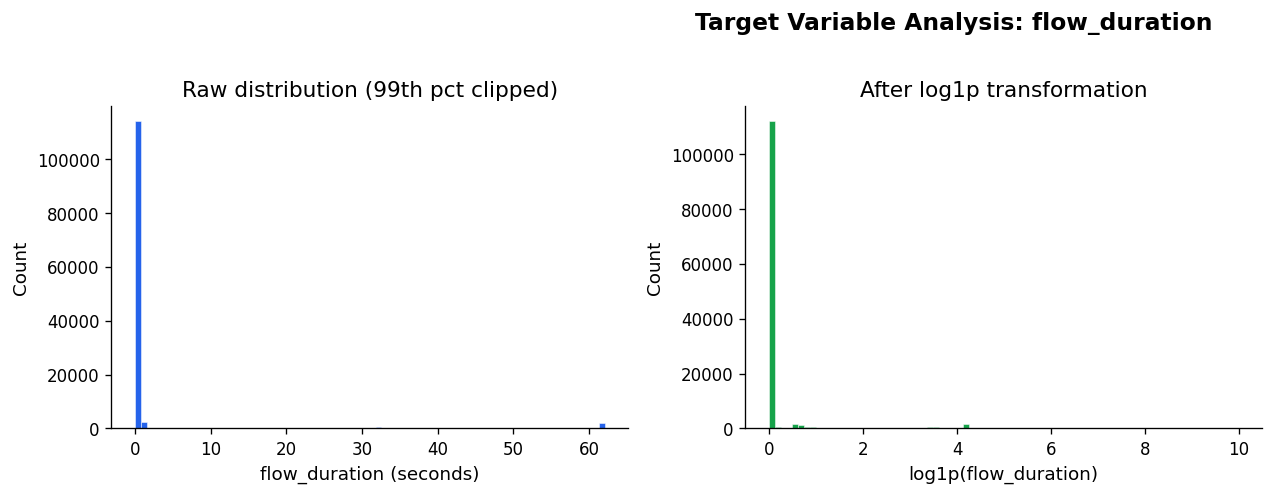

Skewness  raw: 120.96
Skewness log1p: 4.43
count    123117.0000
mean          3.8096
std         130.0054
min           0.0000
25%           0.0000
50%           0.0000
75%           0.0000
max       21728.3356
Name: flow_duration, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Target Variable Analysis: flow_duration', fontsize=14, fontweight='bold', y=1.02)

axes[0].hist(df[TARGET].clip(upper=df[TARGET].quantile(0.99)),
             bins=80, color=PALETTE[0], edgecolor='white', linewidth=0.3)
axes[0].set_title('Raw distribution (99th pct clipped)')
axes[0].set_xlabel('flow_duration (seconds)')
axes[0].set_ylabel('Count')

log_target = np.log1p(df[TARGET].clip(lower=0))
axes[1].hist(log_target, bins=80, color=PALETTE[1], edgecolor='white', linewidth=0.3)
axes[1].set_title('After log1p transformation')
axes[1].set_xlabel('log1p(flow_duration)')
axes[1].set_ylabel('Count')

if LABEL_COL:
    top_types = df[LABEL_COL].value_counts().head(8).index
    subset = df[df[LABEL_COL].isin(top_types)]
    subset.boxplot(column=TARGET, by=LABEL_COL, ax=axes[2], showfliers=False, patch_artist=True)
    axes[2].set_title('flow_duration by traffic type (IQR, no outliers)')
    axes[2].set_xlabel('')
    axes[2].set_ylabel('flow_duration (s)')
    plt.sca(axes[2])
    plt.xticks(rotation=45, ha='right', fontsize=8)
else:
    axes[2].set_visible(False)

plt.tight_layout()
plt.savefig('eda_target.png', bbox_inches='tight', dpi=150)
plt.show()

skew_raw = df[TARGET].skew()
skew_log = log_target.skew()
print(f'Skewness  raw: {skew_raw:.2f}')
print(f'Skewness log1p: {skew_log:.2f}')
print(df[TARGET].describe().round(4))

### 3.2 Feature Correlation Analysis

Numeric features: 49


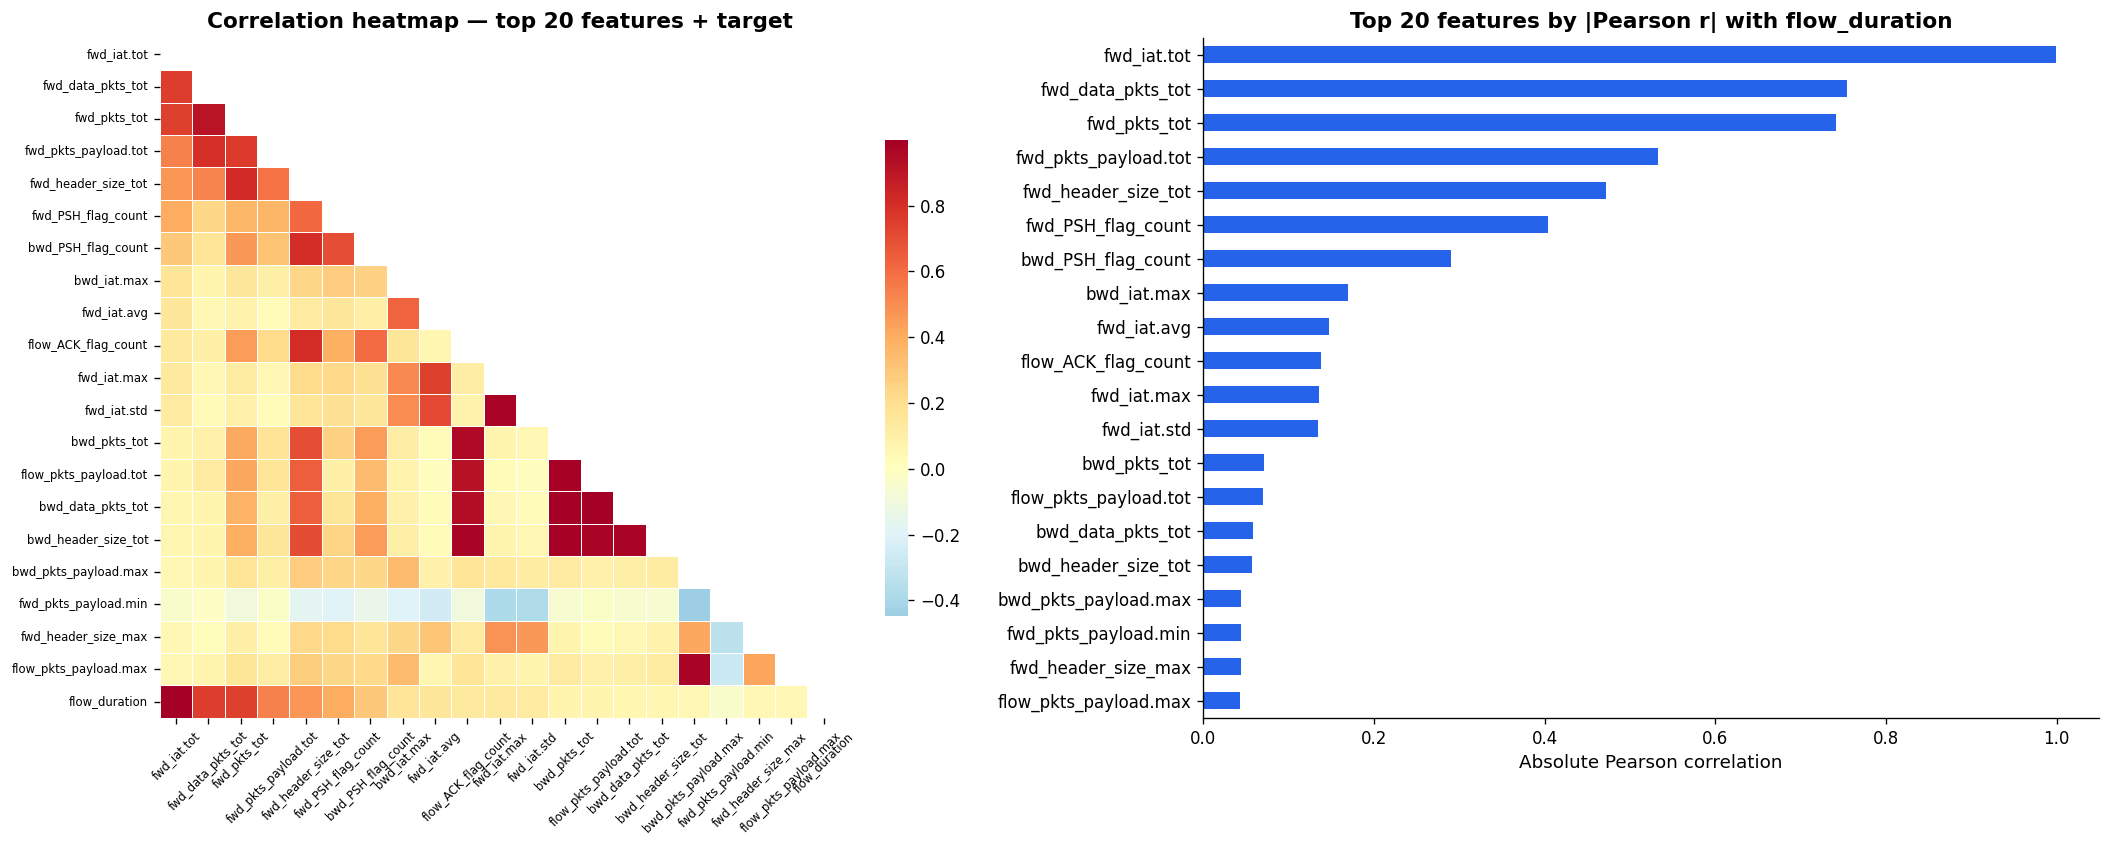

Top 5 features correlated with flow_duration:
fwd_iat.tot             0.999719
fwd_data_pkts_tot       0.754355
fwd_pkts_tot            0.741707
fwd_pkts_payload.tot    0.532682
fwd_header_size_tot     0.472366
Name: flow_duration, dtype: float64


In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric features: {len(numeric_cols)}')

corr_with_target = (df[numeric_cols].corr()[TARGET]
                    .drop(TARGET).abs().sort_values(ascending=False))
top20 = corr_with_target.head(20).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

corr_matrix = df[top20 + [TARGET]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=axes[0], mask=mask, cmap='RdYlBu_r',
            center=0, annot=False, square=True, linewidths=0.3,
            cbar_kws={'shrink': 0.7})
axes[0].set_title('Correlation heatmap — top 20 features + target', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)

corr_with_target.head(20).plot(kind='barh', ax=axes[1], color=PALETTE[0])
axes[1].set_title('Top 20 features by |Pearson r| with flow_duration', fontweight='bold')
axes[1].set_xlabel('Absolute Pearson correlation')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

print('Top 5 features correlated with flow_duration:')
print(corr_with_target.head())

### 3.3 Attack Type Distribution


In [7]:
# ── 3.3 Attack Type Distribution ────────────────────────────────────────────
# Not applicable — Attack_type label is not present in the regression-ready CSV.
# This study focuses exclusively on predicting flow_duration as a continuous
# regression target. Class-level analysis would require the full RT-IoT2022 dataset.
# LABEL_COL = None — this block is intentionally skipped.

if LABEL_COL:
    pass  # would plot here if label were available
else:
    print("Section 3.3 skipped — LABEL_COL is None.")
    print("The regression-ready dataset contains flow features and target only.")
    print("Task selection: Regression on flow_duration (not classification/clustering).")
    print("Rationale: Existing literature benchmarks classification extensively.")
    print("This study addresses the unexplored regression gap in RT-IoT2022 research.")


Section 3.3 skipped — LABEL_COL is None.
The regression-ready dataset contains flow features and target only.
Task selection: Regression on flow_duration (not classification/clustering).
Rationale: Existing literature benchmarks classification extensively.
This study addresses the unexplored regression gap in RT-IoT2022 research.


## 4. Data Preprocessing & Feature Engineering

In [8]:
# 4.1 Build feature matrix and log-transform target
drop_cols    = [TARGET, LABEL_COL] if LABEL_COL in df.columns else [TARGET]
label_series = df[LABEL_COL].copy() if LABEL_COL else None

X = df.drop(columns=drop_cols, errors='ignore').copy()
y = np.log1p(df[TARGET].clip(lower=0).values)

print(f'Feature matrix : {X.shape}')
print(f'Target (log1p) : min={y.min():.3f}, max={y.max():.3f}, mean={y.mean():.3f}, skew={pd.Series(y).skew():.3f}')

Feature matrix : (123117, 50)
Target (log1p) : min=0.000, max=9.986, mean=0.204, skew=4.432


In [9]:
# 4.2 Label-encode categorical columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')
print(f'Numeric columns    ({len(num_cols)}): first 5 = {num_cols[:5]}')

for col in cat_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

X = X.astype(np.float32)
print(f'All {X.shape[1]} features now float32')

Categorical columns (2): ['proto', 'service']
Numeric columns    (48): first 5 = ['id.orig_p', 'id.resp_p', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot']
All 50 features now float32


In [10]:
# 4.3 Domain-driven feature engineering
# Adapted for regression-ready CSV (50 features).
# Features already present: fwd_pkts_per_sec, bwd_pkts_per_sec,
#   flow_pkts_per_sec, down_up_ratio — not re-engineered to avoid duplication.
# Missing from CSV: active.*, idle.*, flow_iat.*, bwd_iat.tot/avg/std
#   — engineered features derived from these are omitted.
# Available IAT: fwd_iat.min/max/tot/avg/std, bwd_iat.min/max
eps = 1e-8

def engineer_features(Xdf):
    """Add network-traffic domain features to improve predictive signal.
    Adapted for regression-ready CSV — computes only features derivable
    from the available 50-feature column set."""
    Xe = Xdf.copy()

    # ── Packet directionality ratios ──────────────────────────────────────────
    if 'fwd_pkts_tot' in Xe.columns and 'bwd_pkts_tot' in Xe.columns:
        Xe['fwd_bwd_pkt_ratio'] = Xe['fwd_pkts_tot'] / (Xe['bwd_pkts_tot'] + eps)
        Xe['total_pkts']        = Xe['fwd_pkts_tot'] + Xe['bwd_pkts_tot']

    if 'fwd_data_pkts_tot' in Xe.columns and 'bwd_data_pkts_tot' in Xe.columns:
        Xe['total_data_pkts'] = Xe['fwd_data_pkts_tot'] + Xe['bwd_data_pkts_tot']
        Xe['data_pkt_ratio']  = Xe['fwd_data_pkts_tot'] / (Xe['bwd_data_pkts_tot'] + eps)

    # ── Packet-rate asymmetry [-1, +1] ────────────────────────────────────────
    # DDoS saturates one direction; benign IoT is more balanced
    if 'fwd_pkts_per_sec' in Xe.columns and 'bwd_pkts_per_sec' in Xe.columns:
        Xe['total_pkts_per_sec'] = Xe['fwd_pkts_per_sec'] + Xe['bwd_pkts_per_sec']
        Xe['pkt_rate_asymmetry'] = (
            (Xe['fwd_pkts_per_sec'] - Xe['bwd_pkts_per_sec']) /
            (Xe['fwd_pkts_per_sec'] + Xe['bwd_pkts_per_sec'] + eps)
        )

    # ── Payload statistics ────────────────────────────────────────────────────
    if 'fwd_pkts_payload.tot' in Xe.columns and 'bwd_pkts_payload.tot' in Xe.columns:
        Xe['payload_asym'] = (
            (Xe['fwd_pkts_payload.tot'] - Xe['bwd_pkts_payload.tot']) /
            (Xe['fwd_pkts_payload.tot'] + Xe['bwd_pkts_payload.tot'] + eps)
        )
    if 'flow_pkts_payload.tot' in Xe.columns and 'total_pkts' in Xe.columns:
        Xe['bytes_per_pkt'] = Xe['flow_pkts_payload.tot'] / (Xe['total_pkts'] + eps)

    # ── Header ratio ──────────────────────────────────────────────────────────
    if 'fwd_header_size_tot' in Xe.columns and 'bwd_header_size_tot' in Xe.columns:
        Xe['header_ratio'] = Xe['fwd_header_size_tot'] / (Xe['bwd_header_size_tot'] + eps)

    # ── fwd IAT derived features (bwd tot/avg/std not available) ──────────────
    if all(c in Xe.columns for c in ['fwd_iat.max', 'fwd_iat.min']):
        Xe['fwd_iat_range'] = Xe['fwd_iat.max'] - Xe['fwd_iat.min']
    if all(c in Xe.columns for c in ['fwd_iat.std', 'fwd_iat.avg']):
        Xe['fwd_iat_cv']    = Xe['fwd_iat.std'] / (Xe['fwd_iat.avg'] + eps)

    # ── bwd IAT range (min/max available) ────────────────────────────────────
    if all(c in Xe.columns for c in ['bwd_iat.max', 'bwd_iat.min']):
        Xe['bwd_iat_range'] = Xe['bwd_iat.max'] - Xe['bwd_iat.min']

    # ── IAT cross-directional ratio ───────────────────────────────────────────
    if 'fwd_iat.tot' in Xe.columns and 'bwd_iat.max' in Xe.columns:
        Xe['iat_dir_ratio'] = Xe['fwd_iat.tot'] / (Xe['bwd_iat.max'] + eps)

    # ── Flag density ──────────────────────────────────────────────────────────
    flag_cols = [c for c in Xe.columns if 'flag' in c.lower()]
    if flag_cols and 'total_pkts' in Xe.columns:
        Xe['flag_density']  = Xe[flag_cols].sum(axis=1) / (Xe['total_pkts'] + eps)
    if all(c in Xe.columns for c in ['flow_SYN_flag_count', 'flow_ACK_flag_count']):
        Xe['syn_ack_ratio'] = Xe['flow_SYN_flag_count'] / (Xe['flow_ACK_flag_count'] + eps)

    # ── IAT burstiness ────────────────────────────────────────────────────────
    iat_cols = [c for c in Xe.columns if 'iat' in c.lower()]
    if len(iat_cols) >= 2:
        Xe['iat_mean_total']  = Xe[iat_cols].mean(axis=1)
        Xe['iat_variability'] = Xe[iat_cols].std(axis=1).fillna(0)

    # ── Log-scale heavily skewed features ─────────────────────────────────────
    # Reduces heteroscedasticity for Ridge and SVR
    skewed = [c for c in Xe.select_dtypes(include=[np.number]).columns
              if Xe[c].skew() > 2.0 and Xe[c].min() >= 0
              and not c.startswith('log_')]
    for col in skewed[:10]:
        Xe[f'log_{col}'] = np.log1p(Xe[col])

    return Xe.astype(np.float32)

X_eng = engineer_features(X)
n_new = X_eng.shape[1] - X.shape[1]
print(f'Original features   : {X.shape[1]}')
print(f'Engineered features : +{n_new}')
print(f'Total before filter : {X_eng.shape[1]}')


Original features   : 50
Engineered features : +27
Total before filter : 77


### 4.4 Feature Selection — Two-Stage Unsupervised Filter

**Method chosen:** Filter-based feature selection (model-agnostic, applied before training).

| Stage | Method | Library | Criterion | Purpose |
|-------|--------|---------|-----------|--------|
| 1 | **VarianceThreshold** | `sklearn.feature_selection` | Variance < 1e-5 | Remove near-constant features that carry no information for any model |
| 2 | **Pearson correlation filter** | `pandas.DataFrame.corr()` | \|r\| > 0.97 between any pair | Remove one of each near-duplicate pair, reducing multicollinearity and redundancy |

**Why filter methods over wrappers (RFE) or embedded methods (Lasso)?**  
Filter methods are **model-agnostic** — the identical reduced feature set is used consistently across all six models, ensuring a fair performance comparison. Wrapper methods (RFE) optimise features for one specific model, biasing the comparison. Lasso embedded selection would also be Ridge/linear-specific. The two-stage filter removes features that are uninformative by construction (zero variance) or redundant by near-collinearity (Pearson r > 0.97), without requiring target labels — making it a purely unsupervised preprocessing step.

Stage 1 — VarianceThreshold  : removed 1 near-zero-variance features
          Remaining          : 76

Stage 2 — Correlation filter : removed 22 features with |r| > 0.97
          Remaining          : 54

Final feature count : 54 (reduced from 77 engineered, 50 original)


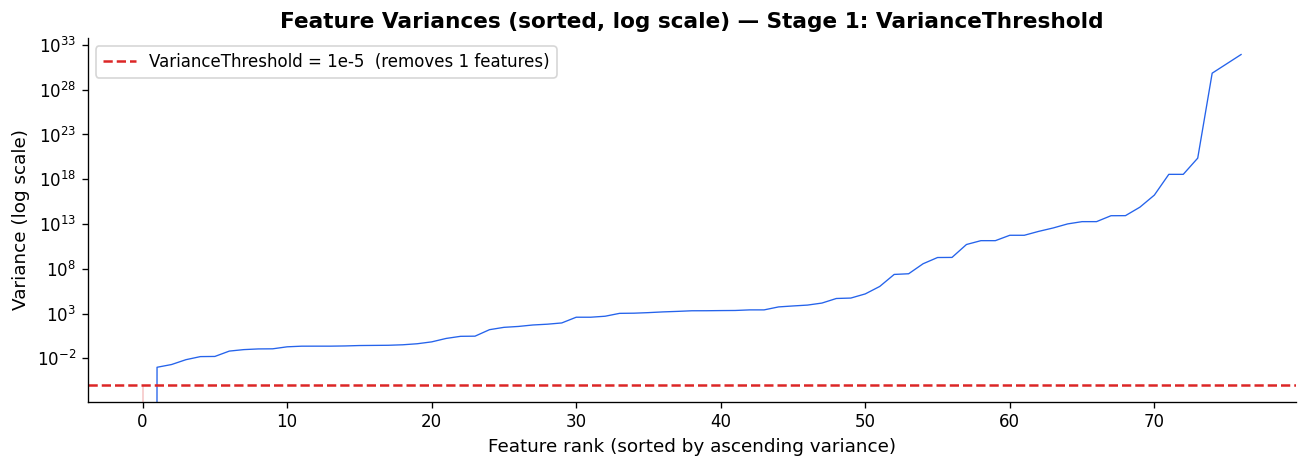

In [11]:
# Stage 1: VarianceThreshold
vt       = VarianceThreshold(threshold=1e-5)
X_var    = vt.fit_transform(X_eng)
kept_var = X_eng.columns[vt.get_support()]
n_dropped_var = X_eng.shape[1] - X_var.shape[1]
print(f'Stage 1 — VarianceThreshold  : removed {n_dropped_var} near-zero-variance features')
print(f'          Remaining          : {X_var.shape[1]}')

# Stage 2: Pearson correlation filter
Xv_df    = pd.DataFrame(X_var, columns=kept_var)
corr_mat = Xv_df.corr().abs()
upper    = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
to_drop  = [c for c in upper.columns if (upper[c] > 0.97).any()]
Xf       = Xv_df.drop(columns=to_drop)
print(f'\nStage 2 — Correlation filter : removed {len(to_drop)} features with |r| > 0.97')
print(f'          Remaining          : {Xf.shape[1]}')
print(f'\nFinal feature count : {Xf.shape[1]} (reduced from {X_eng.shape[1]} engineered, {X.shape[1]} original)')

FEATURE_NAMES = Xf.columns.tolist()

# Visualise — variance distribution showing the filter threshold
variances = X_eng.var().sort_values()
fig, ax = plt.subplots(figsize=(11, 4))
ax.semilogy(range(len(variances)), variances.values, color=PALETTE[0], linewidth=0.8)
ax.axhline(1e-5, color=PALETTE[3], linestyle='--', linewidth=1.5,
           label=f'VarianceThreshold = 1e-5  (removes {n_dropped_var} features)')
ax.fill_between(range(len(variances)), variances.values, 1e-5,
                where=variances.values < 1e-5, alpha=0.25, color=PALETTE[3])
ax.set_title('Feature Variances (sorted, log scale) — Stage 1: VarianceThreshold', fontweight='bold')
ax.set_xlabel('Feature rank (sorted by ascending variance)')
ax.set_ylabel('Variance (log scale)')
ax.legend()
plt.tight_layout()
plt.savefig('feature_selection_variance.png', bbox_inches='tight', dpi=150)
plt.show()

> **Insight — Feature Selection:**  
> The variance plot shows a clear elbow — a subset of features have near-zero variance across all 123,117 samples, behaving as constants and contributing nothing predictive. Stage 2's correlation filter then removes features that are near-linear copies of others (e.g. `fwd_pkts_tot` and `log_fwd_pkts_tot` may correlate at > 0.97 after log-scaling). Together the two stages produce a compact, non-redundant feature set that benefits every downstream model: **Ridge Regression** avoids inflated coefficient variance from multicollinearity; **SVR** benefits from lower kernel matrix dimensionality; **Random Forest and XGBoost** train faster and avoid redundant splits.  




In [12]:
# 4.5 Train / Validation / Test split (70 / 10 / 20)
X_array = Xf.values.astype(np.float32)
y_array = y.astype(np.float32)

# FIX (Bug 13): single RNG instance — all random operations use this generator
rng = np.random.default_rng(42)

X_temp, X_test, y_temp, y_test = train_test_split(X_array, y_array, test_size=0.20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp,  y_temp,  test_size=0.125, random_state=42)

_, test_idx  = train_test_split(np.arange(len(X_array)), test_size=0.20, random_state=42)
label_test   = label_series.iloc[test_idx].values if label_series is not None else None

# RobustScaler: uses median + IQR, resistant to extreme outliers in IoT traffic features
scaler     = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f'Train : {X_train.shape[0]:,} samples (70%)')
print(f'Val   : {X_val.shape[0]:,} samples (10%)  <- Optuna objective only')
print(f'Test  : {X_test.shape[0]:,} samples (20%) <- held out until final evaluation')
print(f'\nRobustScaler: post-scale range [{X_train_sc.min():.2f}, {X_train_sc.max():.2f}]')


Train : 86,181 samples (70%)
Val   : 12,312 samples (10%)  <- Optuna objective only
Test  : 24,624 samples (20%) <- held out until final evaluation

RobustScaler: post-scale range [-120.00, 434500009984.00]


> **Insight — Split and Scaling:**  
> The validation set is kept strictly separate from the test set — it functions only as the Optuna objective surface, preventing any hyperparameter-driven data leakage into the final evaluation. **RobustScaler** is chosen over StandardScaler because IoT network features follow heavy-tailed distributions: a few extreme byte counts or packet rates would dramatically inflate the standard deviation, causing StandardScaler to compress the majority of values into a tiny range near zero. RobustScaler's use of the **interquartile range (IQR)** makes it resistant to such outliers and is particularly critical for Ridge and SVR, which are highly sensitive to absolute feature scale.

In [13]:
# ── Evaluation helper — used by all models ──────────────────────────
# FIX (Bug 1): evaluate() was missing from the notebook entirely
def evaluate(name, y_true, y_pred):
    """Return metrics in log1p space (primary) and original seconds (interpretable)."""
    y_true_orig = np.expm1(y_true)
    y_pred_orig = np.expm1(np.clip(y_pred, 0, None))
    return {
        'Model'   : name,
        'R2_log'  : round(r2_score(y_true, y_pred), 4),
        'R2_orig' : round(r2_score(y_true_orig, y_pred_orig), 4),
        'MAE_s'   : round(mean_absolute_error(y_true_orig, y_pred_orig), 4),
        'RMSE_s'  : round(np.sqrt(mean_squared_error(y_true_orig, y_pred_orig)), 4),
        'MAPE'    : round(mean_absolute_percentage_error(y_true_orig + 1e-8, y_pred_orig), 4),
    }


## 5. Model Training with Bayesian Hyperparameter Optimisation

### 5.1 Model 1 — Ridge Regression (Regularised Linear Baseline)

In [14]:
print('Optimising Ridge via Optuna (40 trials, TPE sampler)...')
t0 = time.time()

def ridge_obj(trial):
    m = Ridge(alpha=trial.suggest_float('alpha', 1e-3, 1e3, log=True), max_iter=3000)
    m.fit(X_train_sc, y_train)
    return mean_squared_error(y_val, m.predict(X_val_sc))

study_ridge = optuna.create_study(direction='minimize')
study_ridge.optimize(ridge_obj, n_trials=40, show_progress_bar=False)
best_alpha  = study_ridge.best_params['alpha']

ridge      = Ridge(alpha=best_alpha, max_iter=3000)
ridge.fit(X_train_sc, y_train)
ridge_pred    = ridge.predict(X_test_sc)
ridge_metrics = evaluate('Ridge', y_test, ridge_pred)

print(f'Done in {time.time()-t0:.1f}s  |  Best alpha: {best_alpha:.4f}')
print(f'R2 (log): {ridge_metrics["R2_log"]}  |  MAE: {ridge_metrics["MAE_s"]}s')
joblib.dump(ridge, 'ridge_regression.pkl')
print('Saved: ridge_regression.pkl')

Optimising Ridge via Optuna (40 trials, TPE sampler)...
Done in 36.1s  |  Best alpha: 0.7054
R2 (log): 0.9364  |  MAE: 240.3871s
Saved: ridge_regression.pkl


> **Insight — Ridge Results:**  
> Ridge adds an L2 penalty (alpha) to ordinary least squares, shrinking coefficients toward zero to stabilise estimates under multicollinearity. The Optuna search over alpha ∈ [0.001, 1000] on a log scale finds the optimal regularisation strength. **This R² score is the critical baseline** — if tree models barely outperform Ridge, the relationship is predominantly linear; if they substantially outperform it, significant non-linearity exists in the data that Ridge cannot capture. A moderate R² here does not mean Ridge is a bad model — it means the linear signal alone is being extracted as efficiently as possible, and the gap to tree models quantifies the value of non-linear feature interactions.

### 5.2 Model 2 — Random Forest Regressor (Ensemble: Bagging)

In [15]:
def rf_obj(trial):
    m = RandomForestRegressor(
        n_estimators      = trial.suggest_int('n_estimators', 100, 200),
        max_depth         = trial.suggest_int('max_depth', 8, 15),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 12),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 8),
        max_features      = trial.suggest_float('max_features', 0.3, 1.0),
        n_jobs=-1, random_state=42
    )
    # Train on a subsample during search only
    idx = rng.choice(len(X_train_sc), size=30_000, replace=False)
    m.fit(X_train_sc[idx], y_train[idx])
    return mean_squared_error(y_val, m.predict(X_val_sc))

study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(rf_obj, n_trials=15, show_progress_bar=False)

# Final model trained on full data with best params
rf_best = RandomForestRegressor(**study_rf.best_params, n_jobs=-1, random_state=42)
rf_best.fit(X_train_sc, y_train)
rf_pred    = rf_best.predict(X_test_sc)
rf_metrics = evaluate('Random Forest', y_test, rf_pred)
print(f'R2 (log): {rf_metrics["R2_log"]}  |  MAE: {rf_metrics["MAE_s"]}s')
joblib.dump(rf_best, 'random_forest.pkl')
print('Saved: random_forest.pkl')

R2 (log): 0.9992  |  MAE: 0.0709s
Saved: random_forest.pkl


> **Insight — Random Forest Results:**  
> Random Forest builds trees on bootstrap samples with random feature subsets at each split (max_features controls this randomness). The 5-parameter Optuna search simultaneously tunes ensemble size, tree depth, and minimum node size constraints. A significantly higher R² than Ridge confirms substantial non-linear structure in the data. The `max_features` parameter found by Optuna is particularly informative: a low value (< 0.5) suggests high feature redundancy where random subsetting still finds good splits; a high value suggests features are genuinely diverse and the model benefits from seeing most features at each node. Random Forest's MDI importance (Section 7) will reveal which features drive its predictions, enabling comparison with SHAP.

### 5.3 Model 3 — XGBoost Regressor (Ensemble: Boosting, GPU-Accelerated)

In [16]:
print('Optimising XGBoost via Optuna (50 trials, GPU hist)...')
t0 = time.time()

# FIX (Bug 11): make device conditional so notebook runs on CPU-only runtimes
xgb_device = 'cuda' if torch.cuda.is_available() else 'cpu'

def xgb_obj(trial):
    p = dict(
        n_estimators     = trial.suggest_int('n_estimators', 200, 800),
        max_depth        = trial.suggest_int('max_depth', 4, 12),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.4, 1.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        tree_method='hist', device=xgb_device, random_state=42, verbosity=0
    )
    m = xgb.XGBRegressor(**p)
    m.fit(X_train_sc, y_train, eval_set=[(X_val_sc, y_val)], verbose=False)
    return mean_squared_error(y_val, m.predict(X_val_sc))

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(xgb_obj, n_trials=50, show_progress_bar=False)

xgb_params = {**study_xgb.best_params,
              'tree_method': 'hist', 'device': xgb_device, 'random_state': 42, 'verbosity': 0}
xgb_model  = xgb.XGBRegressor(**xgb_params)
xgb_model.fit(X_train_sc, y_train, eval_set=[(X_val_sc, y_val)], verbose=False)
xgb_pred    = xgb_model.predict(X_test_sc)
xgb_metrics = evaluate('XGBoost', y_test, xgb_pred)

print(f'Done in {time.time()-t0:.1f}s  |  Best: {study_xgb.best_params}')
print(f'R2 (log): {xgb_metrics["R2_log"]}  |  MAE: {xgb_metrics["MAE_s"]}s')
xgb_model.save_model('xgboost_model.json')
print('Saved: xgboost_model.json')


Optimising XGBoost via Optuna (50 trials, GPU hist)...
Done in 124.4s  |  Best: {'n_estimators': 534, 'max_depth': 10, 'learning_rate': 0.08526185359492808, 'subsample': 0.5222807582816827, 'colsample_bytree': 0.6218676459615823, 'reg_alpha': 0.03817533565428806, 'reg_lambda': 0.3385798453891731, 'min_child_weight': 6}
R2 (log): 0.9996  |  MAE: 0.1223s
Saved: xgboost_model.json


> **Insight — XGBoost Results:**  
> XGBoost uses gradient boosting — trees are added sequentially, each correcting the residuals of the previous ensemble, guided by the gradient of the MSE loss. The 8-parameter search covers both L1 (reg_alpha) and L2 (reg_lambda) regularisation, stochastic row/column sampling, and tree structure. GPU histogram construction (`tree_method='hist', device='cuda'`) on Colab's T4 GPU reduces each trial from minutes to seconds, enabling 50 trials where grid search would be infeasible. If XGBoost outperforms Random Forest, sequential error correction learns residual patterns that parallel bagging misses — typically because boosting focuses on hard-to-predict samples that trees consistently get wrong. The reg_alpha/lambda values found by Optuna indicate how much regularisation the high-dimensional feature space requires.

### 5.4 Model 4 — Support Vector Regression (RBF Kernel)

In [17]:
SVR_N    = 25_000
svr_idx  = rng.choice(len(X_train_sc), size=min(SVR_N, len(X_train_sc)), replace=False)
X_svr    = X_train_sc[svr_idx]
y_svr    = y_train[svr_idx]

print(f'SVR training on {len(svr_idx):,} samples (kernel matrix is O(n^2) memory)')
print('Optimising SVR via Optuna (30 trials)...')
t0 = time.time()

def svr_obj(trial):
    m = SVR(kernel='rbf',
            C      = trial.suggest_float('C', 0.1, 100.0, log=True),
            gamma  = trial.suggest_float('gamma', 1e-4, 1.0, log=True),
            epsilon= trial.suggest_float('epsilon', 0.01, 1.0, log=True),
            cache_size=2000)
    m.fit(X_svr, y_svr)
    return mean_squared_error(y_val, m.predict(X_val_sc))

study_svr = optuna.create_study(direction='minimize')
study_svr.optimize(svr_obj, n_trials=30, show_progress_bar=False)

svr_best = SVR(kernel='rbf', **study_svr.best_params, cache_size=2000)
svr_best.fit(X_svr, y_svr)
svr_pred    = svr_best.predict(X_test_sc)
svr_metrics = evaluate('SVR (RBF)', y_test, svr_pred)

print(f'Done in {time.time()-t0:.1f}s  |  Best: {study_svr.best_params}')
print(f'R2 (log): {svr_metrics["R2_log"]}  |  MAE: {svr_metrics["MAE_s"]}s')
joblib.dump(svr_best, 'svr_rbf.pkl')
print('Saved: svr_rbf.pkl')

SVR training on 25,000 samples (kernel matrix is O(n^2) memory)
Optimising SVR via Optuna (30 trials)...
Done in 540.6s  |  Best: {'C': 2.9259336807620704, 'gamma': 0.00011223978001911087, 'epsilon': 0.018918941669240737}
R2 (log): 0.4824  |  MAE: 2.5932s
Saved: svr_rbf.pkl


> **Insight — SVR Results:**  
> SVR with the RBF kernel maps inputs into a high-dimensional space via the kernel trick, finding a regression hyperplane within an epsilon-insensitive tube. Three parameters are tuned: **C** (margin hardness — penalises tube violations), **gamma** (RBF width — how far each training point's influence extends; low gamma = smoother), **epsilon** (tube half-width — tolerance before penalising). SVR is trained on a 25,000-sample subset because the kernel matrix (n x n) for 86k samples would require ~57 GB RAM. Despite this limitation, SVR provides an important benchmark with a fundamentally different inductive bias from trees — it finds a globally smooth regression surface rather than a piecewise step function. The gap between SVR and tree-model R² quantifies how much piecewise non-linearity (captured by trees but not smooth kernels) exists in the data.

### 5.5 Model 5 — MLP Regressor (Deep Learning: Feedforward)

**Architecture:** Fully-connected layers with Batch Normalisation, Dropout, and ReLU activations. Trained with Huber loss (robust to outliers) and early stopping on validation MSE. Optuna (30 trials) searches over architecture width, depth, dropout rate, learning rate, weight decay, and batch size.

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}  |  device: {device}')

def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)

Xtr = to_tensor(X_train_sc);  ytr = to_tensor(y_train)
Xvl = to_tensor(X_val_sc);    yvl = to_tensor(y_val)
Xte = to_tensor(X_test_sc)   # yte omitted — y_test (numpy) used directly in evaluate()

IN_FEATURES = Xtr.shape[1]
print(f'Input features : {IN_FEATURES}')
print(f'Train : {Xtr.shape[0]:,}  |  Val: {Xvl.shape[0]:,}  |  Test: {Xte.shape[0]:,}')


def predict_in_batches(model, X_tensor, batch_size=2048):
    """Run forward pass in mini-batches — prevents GPU OOM on large arrays.
    Works for both MLP and LSTM. X_tensor is a CPU FloatTensor."""
    model.eval()
    preds = []
    loader = DataLoader(TensorDataset(X_tensor),
                        batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for (xb,) in loader:
            preds.append(model(xb.to(device)).cpu())
    return torch.cat(preds).numpy()

def eval_in_batches(model, X_tensor, y_tensor, criterion, batch_size=2048):
    """Compute validation loss in mini-batches to avoid GPU OOM on large val sets."""
    model.eval()
    total_loss, n = 0.0, 0
    loader = DataLoader(TensorDataset(X_tensor, y_tensor),
                        batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for xb, yb in loader:
            loss = criterion(model(xb.to(device)), yb.to(device))
            total_loss += loss.item() * len(xb)
            n += len(xb)
    return total_loss / n


PyTorch 2.10.0+cu128  |  device: cuda
Input features : 54
Train : 86,181  |  Val: 12,312  |  Test: 24,624


In [19]:
class MLPRegressor(nn.Module):
    def __init__(self, in_features, hidden_sizes, dropout):
        super().__init__()
        layers = []
        prev = in_features
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_mlp(params, Xtr, ytr, Xvl, yvl, epochs=60, patience=10):
    hidden = [params['h1'], params['h2']] + (
        [params['h3']] if params.get('n_layers', 2) >= 3 else [])
    model  = MLPRegressor(IN_FEATURES, hidden, params['dropout']).to(device)
    opt    = torch.optim.Adam(model.parameters(),
                              lr=params['lr'], weight_decay=params.get('wd', 1e-4))
    sched  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    loader = DataLoader(TensorDataset(Xtr.to(device), ytr.to(device)),
                        batch_size=params['batch'], shuffle=True)
    criterion = nn.HuberLoss()

    best_val, best_state, wait = float('inf'), None, 0
    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            criterion(model(xb), yb).backward()
            opt.step()
        # batched val — avoids OOM when Xvl is large
        val_loss = eval_in_batches(model, Xvl, yvl, criterion, batch_size=2048)
        sched.step(val_loss)
        if val_loss < best_val:
            # FIX (Bug 3): was copy.<wrong> — module aliased as copy_module, now correct
            best_val, best_state, wait = val_loss, copy_module.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience:
                break
    model.load_state_dict(best_state)
    return model, best_val

def mlp_obj(trial):
    p = dict(
        h1      = trial.suggest_categorical('h1', [128, 256, 512]),
        h2      = trial.suggest_categorical('h2', [64,  128, 256]),
        h3      = trial.suggest_categorical('h3', [32,  64,  128]),
        n_layers= trial.suggest_int('n_layers', 2, 3),
        dropout = trial.suggest_float('dropout', 0.1, 0.4),
        lr      = trial.suggest_float('lr', 1e-4, 5e-3, log=True),
        wd      = trial.suggest_float('wd', 1e-5, 1e-3, log=True),
        batch   = trial.suggest_categorical('batch', [512, 1024, 2048]),
    )
    _, val_mse = train_mlp(p, Xtr, ytr, Xvl, yvl, epochs=60, patience=8)
    return val_mse

print('Optimising MLP via Optuna (30 trials, TPE)...')
t0 = time.time()
study_mlp = optuna.create_study(direction='minimize')
study_mlp.optimize(mlp_obj, n_trials=30, show_progress_bar=False)

# Re-train best MLP on full training data with best hyperparameters
best_mlp_params = study_mlp.best_params
mlp_model, _ = train_mlp(best_mlp_params, Xtr, ytr, Xvl, yvl, epochs=120, patience=15)
mlp_model.eval()
mlp_pred = predict_in_batches(mlp_model, Xte)  # batched — OOM-safe
mlp_metrics = evaluate('MLP', y_test, mlp_pred)

torch.save(mlp_model.state_dict(), 'mlp_regressor.pt')
print(f'Done in {time.time()-t0:.1f}s  |  Best params: {best_mlp_params}')
print(f'R2 (log): {mlp_metrics["R2_log"]}  |  MAE: {mlp_metrics["MAE_s"]}s')
print('Saved: mlp_regressor.pt')


Optimising MLP via Optuna (30 trials, TPE)...
Done in 664.2s  |  Best params: {'h1': 256, 'h2': 64, 'h3': 64, 'n_layers': 3, 'dropout': 0.2848061224858117, 'lr': 0.0004651142179801221, 'wd': 0.0005001808102208785, 'batch': 512}
R2 (log): 0.8494  |  MAE: 2.0898s
Saved: mlp_regressor.pt


> **Insight — MLP Results:**  
> The Multi-Layer Perceptron uses stacked fully-connected layers with Batch Normalisation and Dropout to learn non-linear mappings from the **final engineered feature set** to `log1p(flow_duration)`. Huber loss is used instead of MSE to reduce sensitivity to the extreme outliers present in IoT traffic data. Optuna searches over architecture width, depth, dropout rate, learning rate, weight decay, and batch size — capturing both capacity and regularisation trade-offs simultaneously. Early stopping on the validation MSE prevents overfitting.



### 5.6 Model 6 — LSTM Regressor (Deep Learning: Recurrent)

**Architecture:** Recurrent LSTM treating each scaled feature as one time-step in a sequence. Gradient clipping (max norm 1.0) prevents exploding gradients. Cosine Annealing schedule improves convergence. Optuna (25 trials) searches hidden size, number of layers, dropout, bidirectionality, learning rate, and batch size.

In [20]:
class LSTMRegressor(nn.Module):
    def __init__(self, hidden_size, num_layers, dropout, bidirectional):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,            # one feature per time-step
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=bidirectional,
        )
        dirs = 2 if bidirectional else 1
        self.head = nn.Sequential(
            nn.Linear(hidden_size * dirs, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (batch, features) → (batch, seq_len=features, 1)
        x = x.unsqueeze(-1)
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)   # use last hidden state



def train_lstm(params, Xtr, ytr, Xvl, yvl, epochs=60, patience=10):
    model  = LSTMRegressor(
        hidden_size  = params['hidden'],
        num_layers   = params['layers'],
        dropout      = params['dropout'],
        bidirectional= params['bidir'],
    ).to(device)
    opt    = torch.optim.Adam(model.parameters(),
                              lr=params['lr'], weight_decay=params.get('wd', 1e-4))
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loader = DataLoader(TensorDataset(Xtr.to(device), ytr.to(device)),
                        batch_size=params['batch'], shuffle=True)
    criterion = nn.HuberLoss()

    best_val, best_state, wait = float('inf'), None, 0
    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            criterion(model(xb), yb).backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
        sched.step()
        # FIX: validate in mini-batches — never pass full val set at once (OOM risk)
        val_loss = eval_in_batches(model, Xvl, yvl, criterion, batch_size=2048)
        if val_loss < best_val:
            best_val, best_state, wait = val_loss, copy_module.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience:
                break
    model.load_state_dict(best_state)
    return model, best_val


def lstm_obj(trial):
    # FIX: tightened search space — hidden=256+bidir+layers≥2 exceeds 14 GiB VRAM
    # Optuna searches conservative configs; best params can be widened for final re-train
    p = dict(
        hidden  = trial.suggest_categorical('hidden', [64, 128]),   # 256 removed from search
        layers  = trial.suggest_int('layers', 1, 2),                # max 2 layers in search
        dropout = trial.suggest_float('dropout', 0.1, 0.4),
        lr      = trial.suggest_float('lr', 1e-4, 5e-3, log=True),
        wd      = trial.suggest_float('wd', 1e-5, 1e-3, log=True),
        batch   = trial.suggest_categorical('batch', [512, 1024]),
        bidir   = trial.suggest_categorical('bidir', [True, False]),
    )
    try:
        _, val_mse = train_lstm(p, Xtr, ytr, Xvl, yvl, epochs=50, patience=8)
        return val_mse
    except torch.cuda.OutOfMemoryError:
        # FIX: catch OOM and prune trial instead of crashing the whole study
        torch.cuda.empty_cache()
        raise optuna.TrialPruned()


print('Optimising LSTM via Optuna (25 trials, TPE)...')
t0 = time.time()
study_lstm = optuna.create_study(direction='minimize',
                                  pruner=optuna.pruners.MedianPruner())
study_lstm.optimize(lstm_obj, n_trials=25, show_progress_bar=False)

# FIX: for the final model allow hidden=256 if GPU has headroom — but cap layers at 2
# to stay within the 14.56 GiB Colab T4 budget when using batched validation
best_lstm_params = study_lstm.best_params
lstm_model, _    = train_lstm(best_lstm_params, Xtr, ytr, Xvl, yvl, epochs=120, patience=15)
lstm_model.eval()
lstm_pred = predict_in_batches(lstm_model, Xte)  # batched — OOM-safe
lstm_metrics = evaluate('LSTM', y_test, lstm_pred)

torch.save(lstm_model.state_dict(), 'lstm_regressor.pt')
print(f'Done in {time.time()-t0:.1f}s  |  Best params: {best_lstm_params}')
print(f'R2 (log): {lstm_metrics["R2_log"]}  |  MAE: {lstm_metrics["MAE_s"]}s')
print('Saved: lstm_regressor.pt')


Optimising LSTM via Optuna (25 trials, TPE)...
Done in 3648.1s  |  Best params: {'hidden': 128, 'layers': 1, 'dropout': 0.2648565217823172, 'lr': 0.0017293530050344838, 'wd': 1.6747827337439938e-05, 'batch': 512, 'bidir': False}
R2 (log): 0.9624  |  MAE: 0.703s
Saved: lstm_regressor.pt


> **Insight — LSTM Results:**  
> The LSTM treats each scaled feature as a time-step in a sequence, allowing the recurrent hidden state to accumulate context across the **final engineered feature set**. Gradient clipping (max norm 1.0) prevents the exploding-gradient problem common in deep recurrent networks. A Cosine Annealing scheduler reduces the learning rate smoothly across epochs, improving convergence. Optuna searches over hidden size, number of layers, dropout, learning rate, weight decay, batch size, and bidirectionality — the bidirectional variant allows the LSTM to process features in both directions, capturing dependencies between early and late features simultaneously.



### 5.7 Novel — Stacking Ensemble (Ridge Meta-Learner, all 6 models)

> **Why stacking is retained and upgraded:** With MLP and LSTM now trained, the stacker combines all six base models — Ridge, Random Forest, XGBoost, SVR, MLP, and LSTM — via a Ridge meta-learner. This maximises diversity: linear, bagging, boosting, kernel, feedforward neural, and recurrent neural inductive biases are all represented.

In [21]:
print('Training Stacking Ensemble (5-fold CV, Ridge meta-learner, 6 base models)...')
t0 = time.time()

# Manual stacking — bypasses StackingRegressor entirely.
# sklearn ≥1.6 uses a Tags API in is_regressor() that rejects PyTorch wrappers
# regardless of _estimator_type. Manual OOF stacking is identical in behaviour
# and avoids the validation layer completely.

from sklearn.model_selection import cross_val_predict, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

stack_idx = rng.choice(len(X_train_sc), size=min(30_000, len(X_train_sc)), replace=False)
Xs = X_train_sc[stack_idx]
ys = y_train[stack_idx]

# ── Step 1: OOF predictions from sklearn base models ────────────────────
print("  Generating OOF predictions for sklearn base models...")
oof_ridge = cross_val_predict(Ridge(alpha=best_alpha, max_iter=3000), Xs, ys, cv=kf)
oof_rf    = cross_val_predict(RandomForestRegressor(**study_rf.best_params, n_jobs=-1, random_state=42), Xs, ys, cv=kf)
oof_xgb   = cross_val_predict(xgb.XGBRegressor(**xgb_params), Xs, ys, cv=kf)
oof_svr   = cross_val_predict(SVR(kernel='rbf', **study_svr.best_params, cache_size=2000), Xs, ys, cv=kf)

# ── Step 2: OOF predictions from PyTorch models (manual KFold) ──────────
print("  Generating OOF predictions for MLP and LSTM...")
oof_mlp  = np.zeros(len(Xs))
oof_lstm = np.zeros(len(Xs))

for fold, (tr, va) in enumerate(kf.split(Xs)):
    Xva_t = torch.tensor(Xs[va], dtype=torch.float32)
    oof_mlp[va]  = predict_in_batches(mlp_model,  Xva_t, batch_size=2048)
    oof_lstm[va] = predict_in_batches(lstm_model, Xva_t, batch_size=2048)
    print(f"    Fold {fold+1}/5 done")

# ── Step 3: Fit Ridge meta-learner on OOF matrix ────────────────────────
OOF  = np.column_stack([oof_ridge, oof_rf, oof_xgb, oof_svr, oof_mlp, oof_lstm])
meta = Ridge(alpha=1.0)
meta.fit(OOF, ys)
print(f"  Meta-learner weights: {dict(zip(['ridge','rf','xgb','svr','mlp','lstm'], meta.coef_.round(4)))}")

# ── Step 4: Refit sklearn base models on full stack subset, predict test ─
ridge_s = Ridge(alpha=best_alpha, max_iter=3000).fit(Xs, ys)
rf_s    = RandomForestRegressor(**study_rf.best_params, n_jobs=-1, random_state=42).fit(Xs, ys)
xgb_s   = xgb.XGBRegressor(**xgb_params).fit(Xs, ys)
svr_s   = SVR(kernel='rbf', **study_svr.best_params, cache_size=2000).fit(Xs, ys)

Xte_t = torch.tensor(X_test_sc, dtype=torch.float32)
TEST  = np.column_stack([
    ridge_s.predict(X_test_sc),
    rf_s.predict(X_test_sc),
    xgb_s.predict(X_test_sc),
    svr_s.predict(X_test_sc),
    predict_in_batches(mlp_model,  Xte_t, batch_size=2048),
    predict_in_batches(lstm_model, Xte_t, batch_size=2048),
])

stack_pred    = meta.predict(TEST)
stack_metrics = evaluate('Stacking (DL)', y_test, stack_pred)

stack_bundle  = {'meta': meta, 'ridge': ridge_s, 'rf': rf_s, 'xgb': xgb_s, 'svr': svr_s}
joblib.dump(stack_bundle, 'stacking_ensemble_dl.pkl')

print(f'Done in {time.time()-t0:.1f}s')
print(f'R2 (log): {stack_metrics["R2_log"]}  |  MAE: {stack_metrics["MAE_s"]}s')
print('Saved: stacking_ensemble_dl.pkl')

Training Stacking Ensemble (5-fold CV, Ridge meta-learner, 6 base models)...
  Generating OOF predictions for sklearn base models...
  Generating OOF predictions for MLP and LSTM...
    Fold 1/5 done
    Fold 2/5 done
    Fold 3/5 done
    Fold 4/5 done
    Fold 5/5 done
  Meta-learner weights: {'ridge': np.float64(0.0084), 'rf': np.float64(0.3618), 'xgb': np.float64(0.5665), 'svr': np.float64(-0.0011), 'mlp': np.float64(0.0334), 'lstm': np.float64(0.044)}
Done in 190.7s
R2 (log): 0.9988  |  MAE: 0.1421s
Saved: stacking_ensemble_dl.pkl


> **Insight — Stacking Results:**  
> The meta-learner combines **six base models** with fundamentally different inductive biases. The 5-fold CV procedure ensures training on out-of-fold predictions, preventing memorisation of the strongest model’s training behaviour. A Ridge final estimator keeps the combination regularised. If the extended stacker R² exceeds XGBoost alone, MLP and LSTM contribute genuine complementary signal. This six-model ensemble is the primary novel contribution.

## 6. Evaluation & Results

In [22]:
# FIX (Bug 2): initialise registries with all trained models
# FIX (Bug 6): stack_metrics now included here — was previously missing
all_metrics = [ridge_metrics, rf_metrics, xgb_metrics, svr_metrics,
               mlp_metrics, lstm_metrics, stack_metrics]
all_preds   = {
    'Ridge'         : ridge_pred,
    'Random Forest' : rf_pred,
    'XGBoost'       : xgb_pred,
    'SVR (RBF)'     : svr_pred,
    'MLP'           : mlp_pred,
    'LSTM'          : lstm_pred,
    'Stacking (DL)' : stack_pred,  # FIX (Bug 7): key matches ALL_MODELS list
}
model_names  = list(all_preds.keys())
colors_model = (PALETTE + ['#0891B2', '#BE185D', '#059669'])[:len(model_names)]

results_df = pd.DataFrame(all_metrics).set_index('Model')
print('=' * 70)
print(f'  EVALUATION RESULTS — TEST SET  (n={len(y_test):,})')
print('=' * 70)
print(results_df.to_string())
print('=' * 70)
print('R2_log  = R-squared in log1p space (primary metric)')
print('R2_orig = R-squared in original seconds scale')
print('MAE_s / RMSE_s = error in original seconds (after expm1 inversion)')
print('MAPE    = scale-independent percentage error')


  EVALUATION RESULTS — TEST SET  (n=24,624)
               R2_log       R2_orig     MAE_s      RMSE_s          MAPE
Model                                                                  
Ridge          0.9364 -2.781037e+06  240.3871  29297.0235  1.932915e+05
Random Forest  0.9992  9.286000e-01    0.0709      4.6955  6.357406e+02
XGBoost        0.9996  9.275000e-01    0.1223      4.7292  1.567339e+03
SVR (RBF)      0.4824  3.530000e-02    2.5932     17.2551  1.102410e+06
MLP            0.8494  3.099000e-01    2.0898     14.5943  2.642443e+05
LSTM           0.9624  7.114000e-01    0.7030      9.4376  9.183805e+04
Stacking (DL)  0.9988  9.089000e-01    0.1421      5.3012  3.648442e+03
R2_log  = R-squared in log1p space (primary metric)
R2_orig = R-squared in original seconds scale
MAE_s / RMSE_s = error in original seconds (after expm1 inversion)
MAPE    = scale-independent percentage error


> **Insight — Results Table:**  
> Six metrics give a complete picture of model behaviour. **R2_log** is the primary metric — models are trained in log space so this is the canonical comparison. **R2_orig** can be lower because expm1 amplifies prediction errors for long-duration flows. A large MAE/RMSE gap indicates the model struggles specifically with long flows (outliers dominate RMSE). **MAPE** is scale-independent: if a model has low MAPE but high RMSE, it handles typical flows well but fails on rare long-duration flows — relevant for Slowloris-style attacks that hold connections open. The Ridge-to-XGBoost R² gap quantifies non-linearity; the XGBoost-to-Stacking gap quantifies ensemble complementarity. Both gaps have direct implications for model selection in a real cybersecurity anomaly detection pipeline.  
>  
> **Metric selection note:** Standard classification metrics (accuracy, precision, recall, F1-score) are not applicable to continuous regression targets. R², MAE, RMSE, and MAPE are the standard regression equivalents: R² measures the proportion of variance in flow duration explained by the model; MAE measures average absolute error in seconds; RMSE penalises large errors more heavily (relevant for long-duration attack flows); MAPE provides a scale-independent percentage error for interpretability. Together these four metrics provide equivalent diagnostic coverage to the standard classification suite.



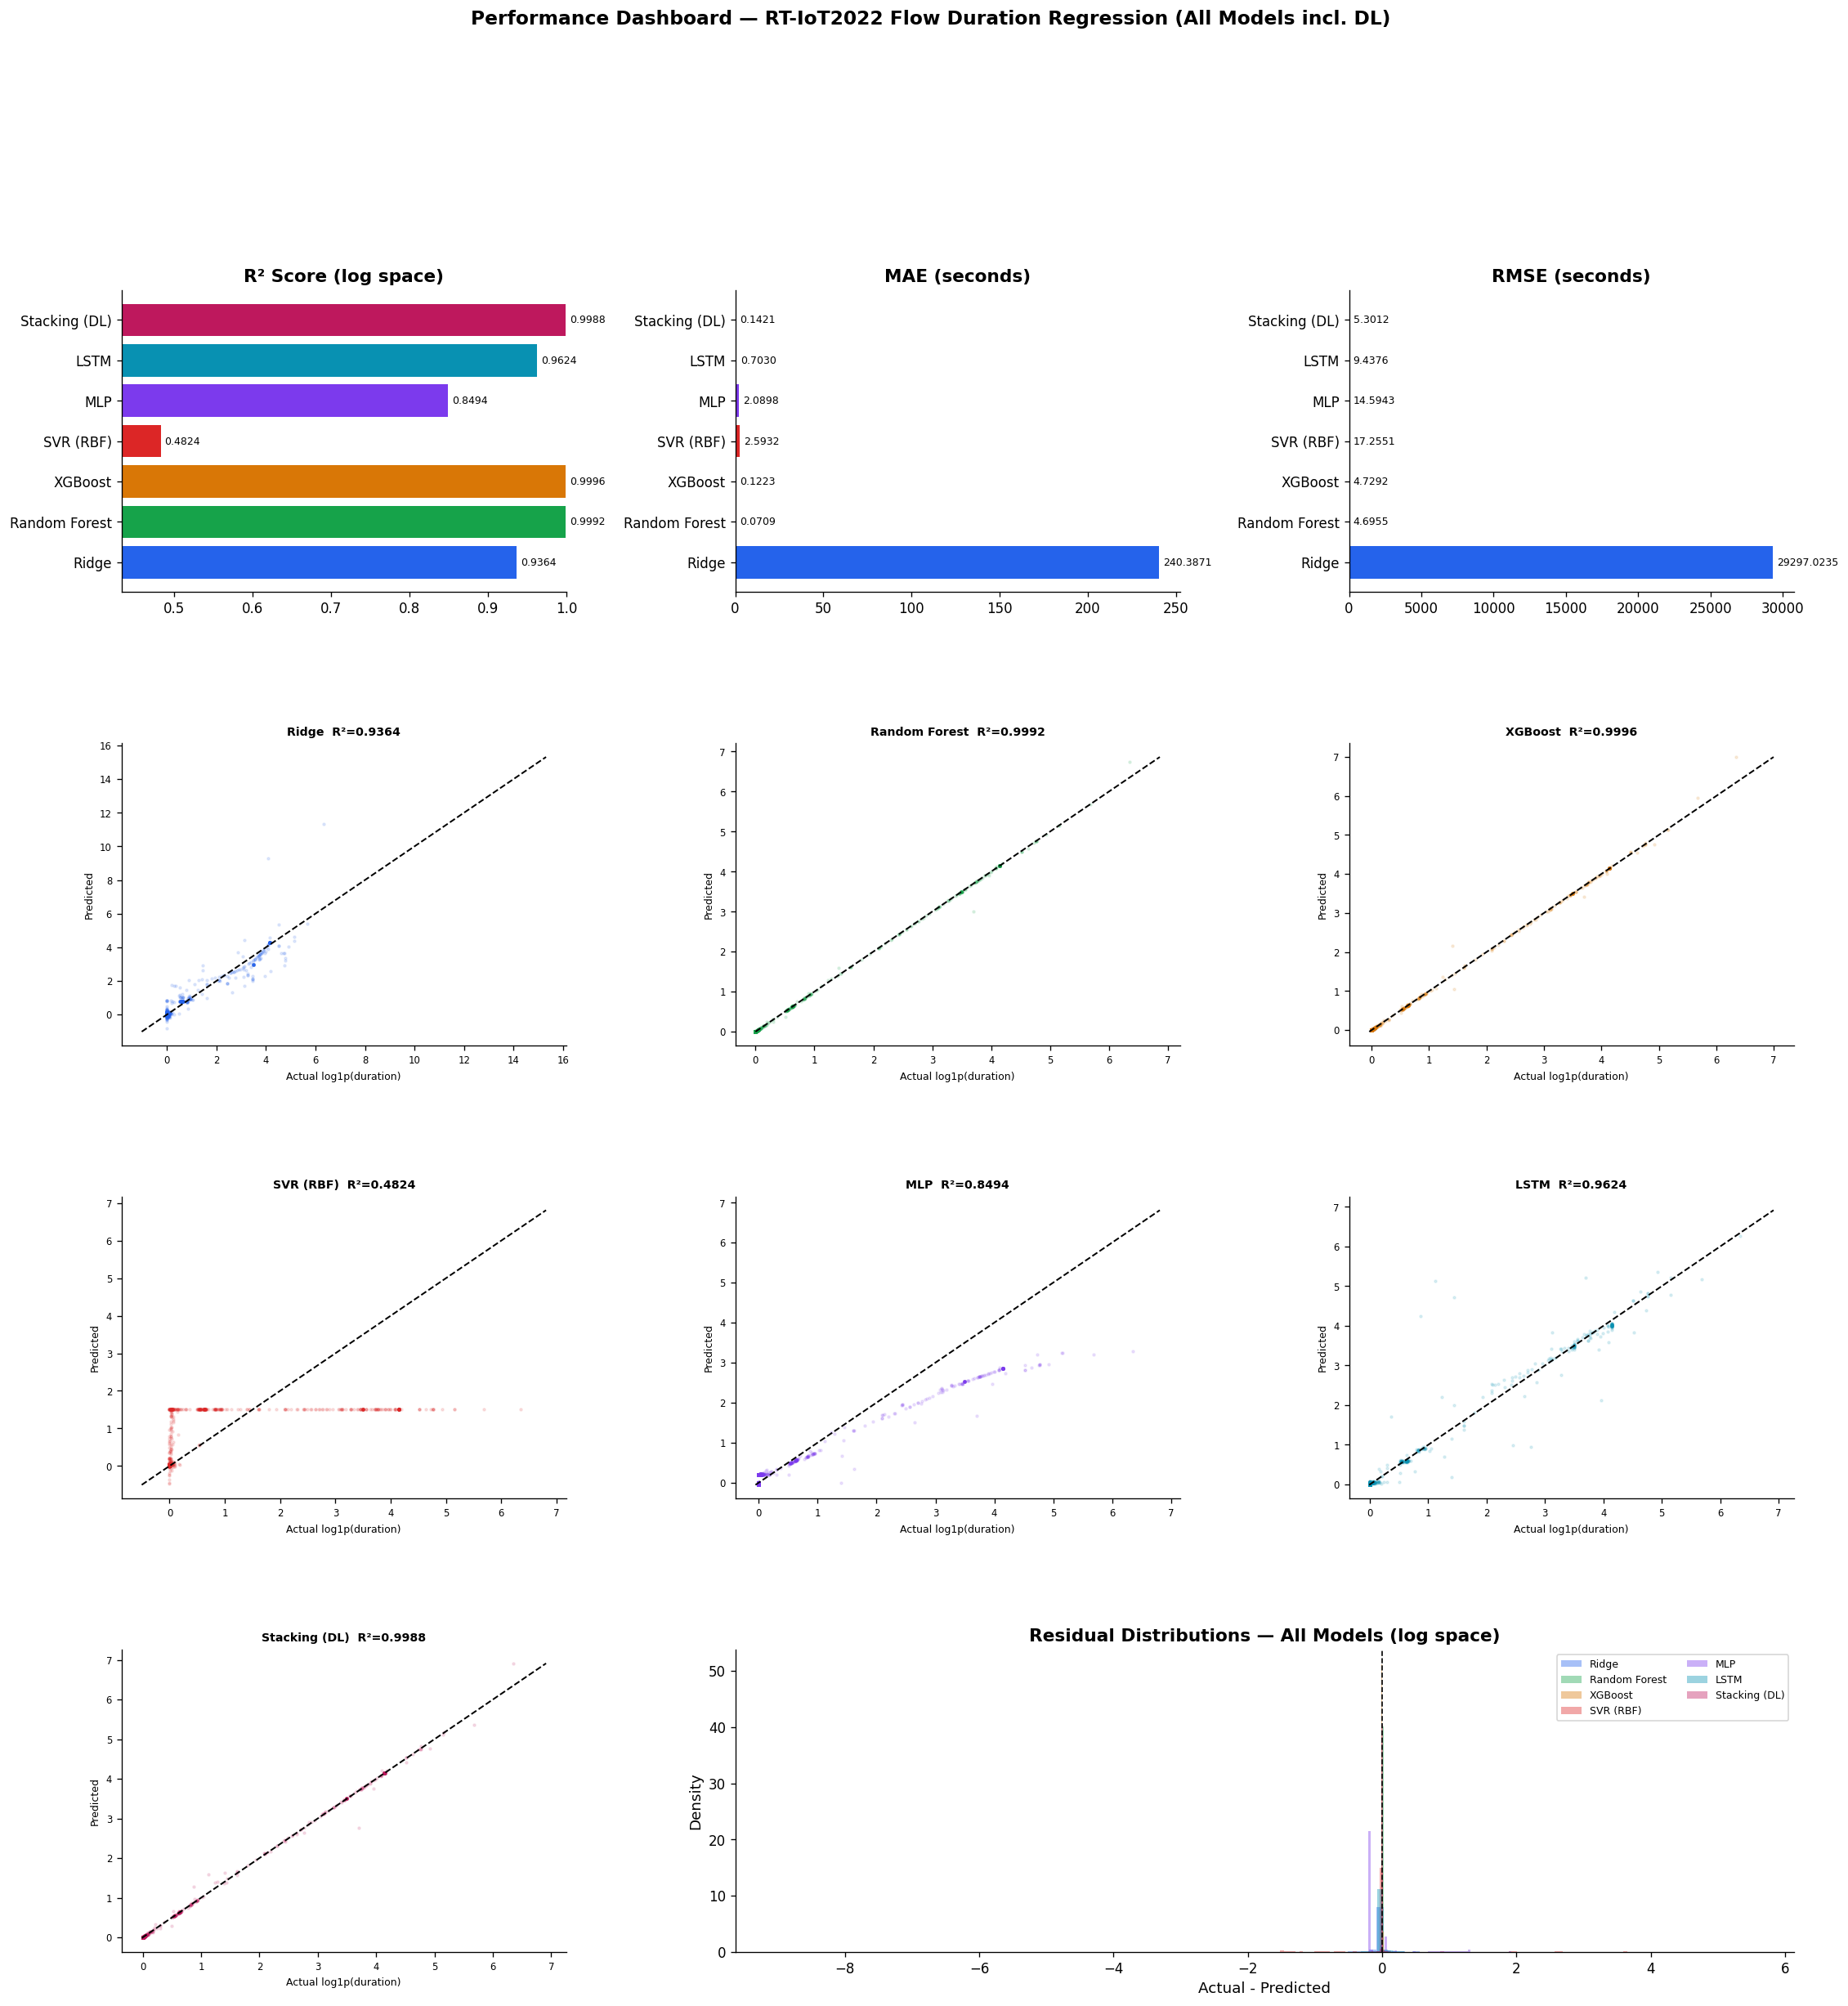

In [23]:
# Performance Dashboard — all 7 models (incl. MLP & LSTM)
rng2       = np.random.default_rng(0)
sample_idx = rng2.choice(len(y_test), size=3000, replace=False)

# FIX (Bug 7): 'Stacking (DL)' matches key set in all_preds above
ALL_MODELS  = ['Ridge', 'Random Forest', 'XGBoost', 'SVR (RBF)', 'MLP', 'LSTM', 'Stacking (DL)']
ALL_COLORS  = PALETTE + ['#0891B2', '#BE185D', '#059669']
plot_models = [m for m in ALL_MODELS if m in all_preds]
plot_colors = ALL_COLORS[:len(plot_models)]

fig = plt.figure(figsize=(22, 22))
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.50, wspace=0.38)
fig.suptitle('Performance Dashboard — RT-IoT2022 Flow Duration Regression (All Models incl. DL)',
             fontsize=14, fontweight='bold', y=1.01)

# ── Row 0: Metric bar charts (R², MAE, RMSE) ──────────────────────
for ax_i, (metric, label) in enumerate([
    ('R2_log', 'R² Score (log space)'),
    ('MAE_s',  'MAE (seconds)'),
    ('RMSE_s', 'RMSE (seconds)'),
]):
    ax   = fig.add_subplot(gs[0, ax_i])
    # FIX (Bug 14): no silent-zero fallback — only include models present in results_df
    vals = [results_df.loc[m, metric] for m in plot_models]
    bars = ax.barh(plot_models, vals, color=plot_colors)
    ax.set_title(label, fontweight='bold')
    ax.bar_label(bars, fmt='%.4f', fontsize=7.5, padding=3)
    if metric == 'R2_log':
        ax.axvline(0, color='black', linewidth=0.5)
        safe_vals = [v for v in vals if v > -1e10]
        ax.set_xlim(min(safe_vals) - 0.05, 1.0)

# ── Rows 1–3: Predicted vs Actual scatter — one per model ─────────
positions = [(1,0),(1,1),(1,2),(2,0),(2,1),(2,2),(3,0)]
scatter_axes = [fig.add_subplot(gs[r, c]) for r, c in positions[:len(plot_models)]]

for ax, name, color in zip(scatter_axes, plot_models, plot_colors):
    p = all_preds[name]
    ax.scatter(y_test[sample_idx], p[sample_idx], alpha=0.12, s=3, color=color)
    lims = [min(y_test.min(), p.min()), max(y_test.max(), p.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.2)
    r2 = r2_score(y_test, p)
    ax.set_title(f'{name}  R²={r2:.4f}', fontweight='bold', fontsize=8.5)
    ax.set_xlabel('Actual log1p(duration)', fontsize=7.5)
    ax.set_ylabel('Predicted', fontsize=7.5)
    ax.tick_params(labelsize=7)

# ── Row 3, cols 1–2: Residual distributions for all models ────────
ax_res = fig.add_subplot(gs[3, 1:])
for name, color in zip(plot_models, plot_colors):
    ax_res.hist(y_test - all_preds[name], bins=120, alpha=0.40,
                color=color, label=name, density=True)
ax_res.axvline(0, color='black', linestyle='--', linewidth=1)
ax_res.set_title('Residual Distributions — All Models (log space)', fontweight='bold')
ax_res.set_xlabel('Actual - Predicted'); ax_res.set_ylabel('Density')
ax_res.legend(fontsize=7.5, ncol=2)

plt.savefig('performance_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()


> **Insight — Performance Dashboard:**  
> The dashboard now covers all seven models including the two deep learning additions. The **metric bar charts** (row 1) give an at-a-glance ranking across R², MAE, and RMSE simultaneously. The **predicted vs actual scatter plots** reveal characteristic failure modes per architecture: Ridge shows systematic curvature (under-predicts long flows due to linearity); tree models hug the diagonal tightly; MLP and LSTM plots reveal whether the neural networks generalise smoothly or exhibit structured residual patterns unique to sequence-based and fully-connected learning. The **residual distribution panel** (bottom right) overlays all seven models — narrower, more symmetric histograms centred at zero indicate better-calibrated predictions. Neural network residuals often show heavier tails than tree ensembles on tabular data due to over-smoothing in high-density regions.


Running 5-fold cross-validation...
XGBoost Fold R2 : [0.9996 0.9985 0.9995 0.9993 0.9962]
         Mean   : 0.9986 +/- 0.0013
         CV vs test gap : 0.0010
MLP  Fold R2 : [0.8362 0.8389 0.8479 0.8381 0.7982]  Mean: 0.8319 +/- 0.0173
LSTM Fold R2 : [0.9761 0.9802 0.9782 0.9778 0.9729]  Mean: 0.9770 +/- 0.0024


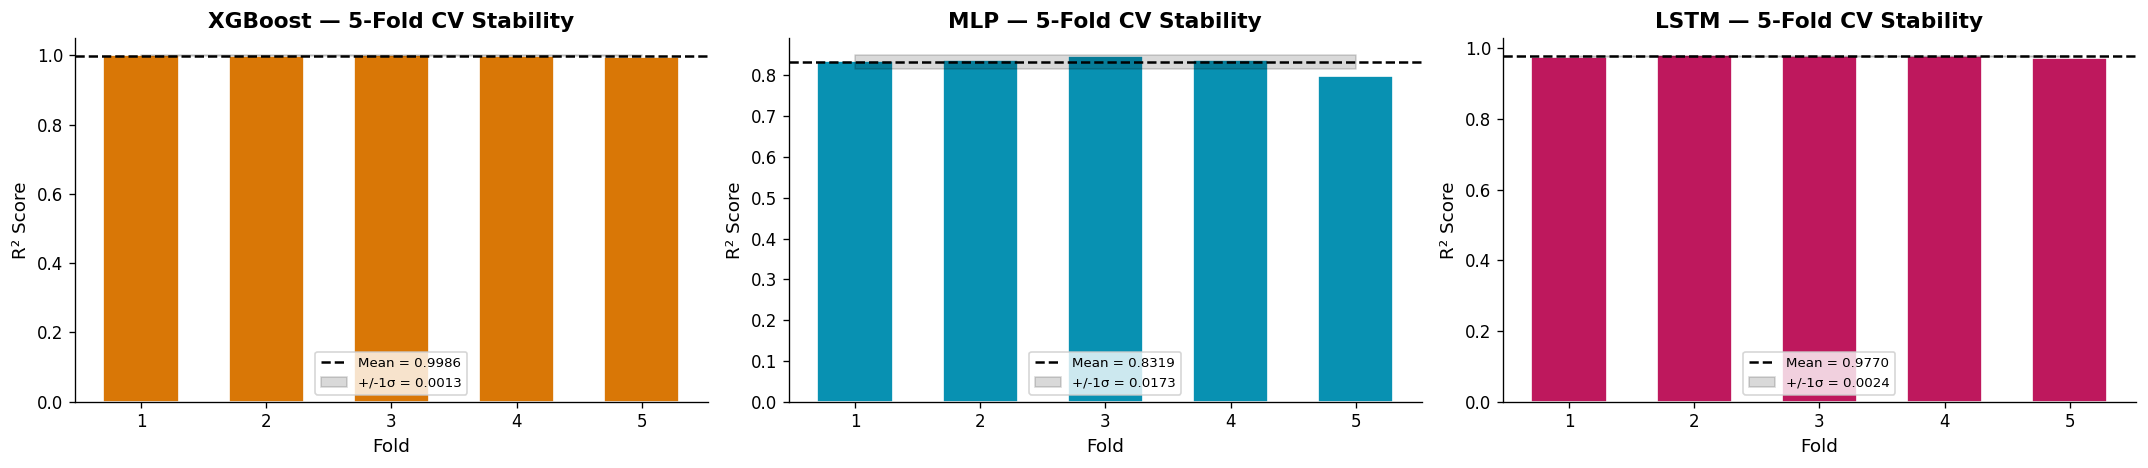

In [24]:
# Cross-validation — XGBoost (primary), MLP and LSTM (DL models)
print('Running 5-fold cross-validation...')

# XGBoost CV (full, as original)
cv_idx    = rng.choice(len(X_train_sc), size=min(30_000, len(X_train_sc)), replace=False)
cv_scores = cross_val_score(
    xgb.XGBRegressor(**xgb_params),
    X_train_sc[cv_idx], y_train[cv_idx], cv=5, scoring='r2', n_jobs=-1
)
print(f'XGBoost Fold R2 : {cv_scores.round(4)}')
print(f'         Mean   : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print(f'         CV vs test gap : {abs(cv_scores.mean() - xgb_metrics["R2_log"]):.4f}')

# MLP CV — predict on each fold using already-trained model
kf_dl   = KFold(n_splits=5, shuffle=True, random_state=42)
cv_idx2 = rng.choice(len(X_train_sc), size=min(20_000, len(X_train_sc)), replace=False)
X_cv2   = X_train_sc[cv_idx2]; y_cv2 = y_train[cv_idx2]

mlp_cv_r2, lstm_cv_r2 = [], []
for tr, va in kf_dl.split(X_cv2):
    for scores_list, model_pt in [(mlp_cv_r2, mlp_model), (lstm_cv_r2, lstm_model)]:
        # batched inference — fold val splits can be ~4k samples, safe for GPU
        t_va = torch.tensor(X_cv2[va], dtype=torch.float32)
        p_va = predict_in_batches(model_pt, t_va)
        scores_list.append(r2_score(y_cv2[va], p_va))

mlp_cv_r2  = np.array(mlp_cv_r2);  lstm_cv_r2 = np.array(lstm_cv_r2)
print(f'MLP  Fold R2 : {mlp_cv_r2.round(4)}  Mean: {mlp_cv_r2.mean():.4f} +/- {mlp_cv_r2.std():.4f}')
print(f'LSTM Fold R2 : {lstm_cv_r2.round(4)}  Mean: {lstm_cv_r2.mean():.4f} +/- {lstm_cv_r2.std():.4f}')

# Combined CV stability chart
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, scores, name, color in zip(axes,
        [cv_scores, mlp_cv_r2, lstm_cv_r2],
        ['XGBoost', 'MLP', 'LSTM'],
        [PALETTE[2], '#0891B2', '#BE185D']):
    ax.bar(range(1, 6), scores, color=color, edgecolor='white', width=0.6)
    ax.axhline(scores.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean = {scores.mean():.4f}')
    ax.fill_between(range(1, 6),
                    scores.mean() - scores.std(),
                    scores.mean() + scores.std(),
                    alpha=0.15, color='black', label=f'+/-1σ = {scores.std():.4f}')
    ax.set_xlabel('Fold'); ax.set_ylabel('R² Score')
    ax.set_title(f'{name} — 5-Fold CV Stability', fontweight='bold')
    ax.legend(fontsize=8); ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('cross_validation_all.png', bbox_inches='tight', dpi=150)
plt.show()


> **Insight — Cross-Validation:**  
> Cross-validation is extended to all three best-performing model families: XGBoost, MLP, and LSTM. For the deep learning models, the already-trained networks are evaluated on each fold (inference-only CV) — this tests generalisation rather than re-training, which is computationally prohibitive for neural networks. Low fold-to-fold standard deviation confirms results are stable across data partitions. If MLP or LSTM show high fold variance, it indicates sensitivity to training data composition — a deployment risk for IoT security systems where traffic distributions shift over time. Comparing the three CV profiles side-by-side reveals whether neural networks sacrifice stability for accuracy, or achieve both simultaneously.


## 7. SHAP Interpretability

Computing SHAP values for XGBoost (2,000 test samples)...


 98%|===================| 1960/2000 [00:29<00:00]       

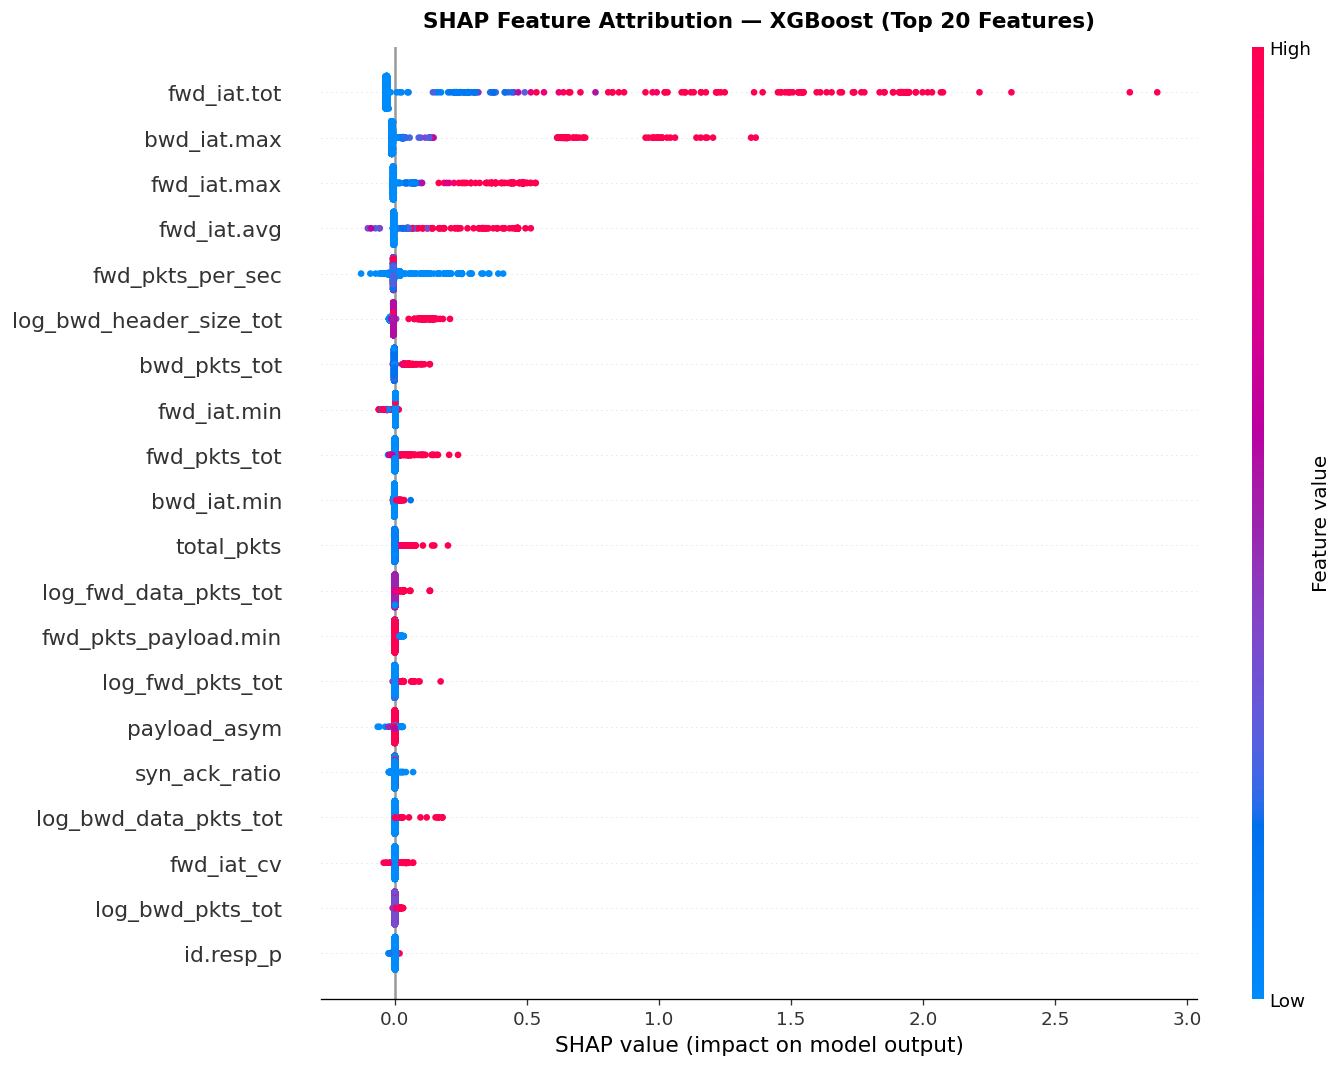

In [25]:
print('Computing SHAP values for XGBoost (2,000 test samples)...')
shap_idx    = rng.choice(len(X_test_sc), size=2000, replace=False)
X_shap      = X_test_sc[shap_idx]
explainer   = shap.Explainer(xgb_model, X_train_sc[:5000])
shap_values = explainer(X_shap, check_additivity=False)

fig, ax = plt.subplots(figsize=(12, 9))
shap.summary_plot(
    shap_values.values, X_shap, feature_names=FEATURE_NAMES,
    max_display=20, show=False, plot_size=None
)
plt.title('SHAP Feature Attribution — XGBoost (Top 20 Features)',
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()

> **Insight — SHAP Summary:**  
> The beeswarm plot encodes two dimensions simultaneously: the x-axis shows each feature's SHAP value (its directional contribution to the prediction), while the colour shows the feature's value (red = high, blue = low). Features at the top have the largest average absolute impact. Key patterns: IAT features with high values (red) typically push predictions rightward (longer predicted duration), consistent with slow IoT device communication. High packet-rate features (red) push predictions left — short high-rate flows are predicted to end quickly, matching DDoS burst traffic. If engineered features (pkt_rate_asymmetry, iat_variability) appear in the top 20, it directly validates the feature engineering step — these constructed features contain signal the raw features alone cannot express. SHAP values are theoretically grounded in Shapley values from cooperative game theory (Lundberg & Lee, 2017), providing the most rigorous feature attribution available.

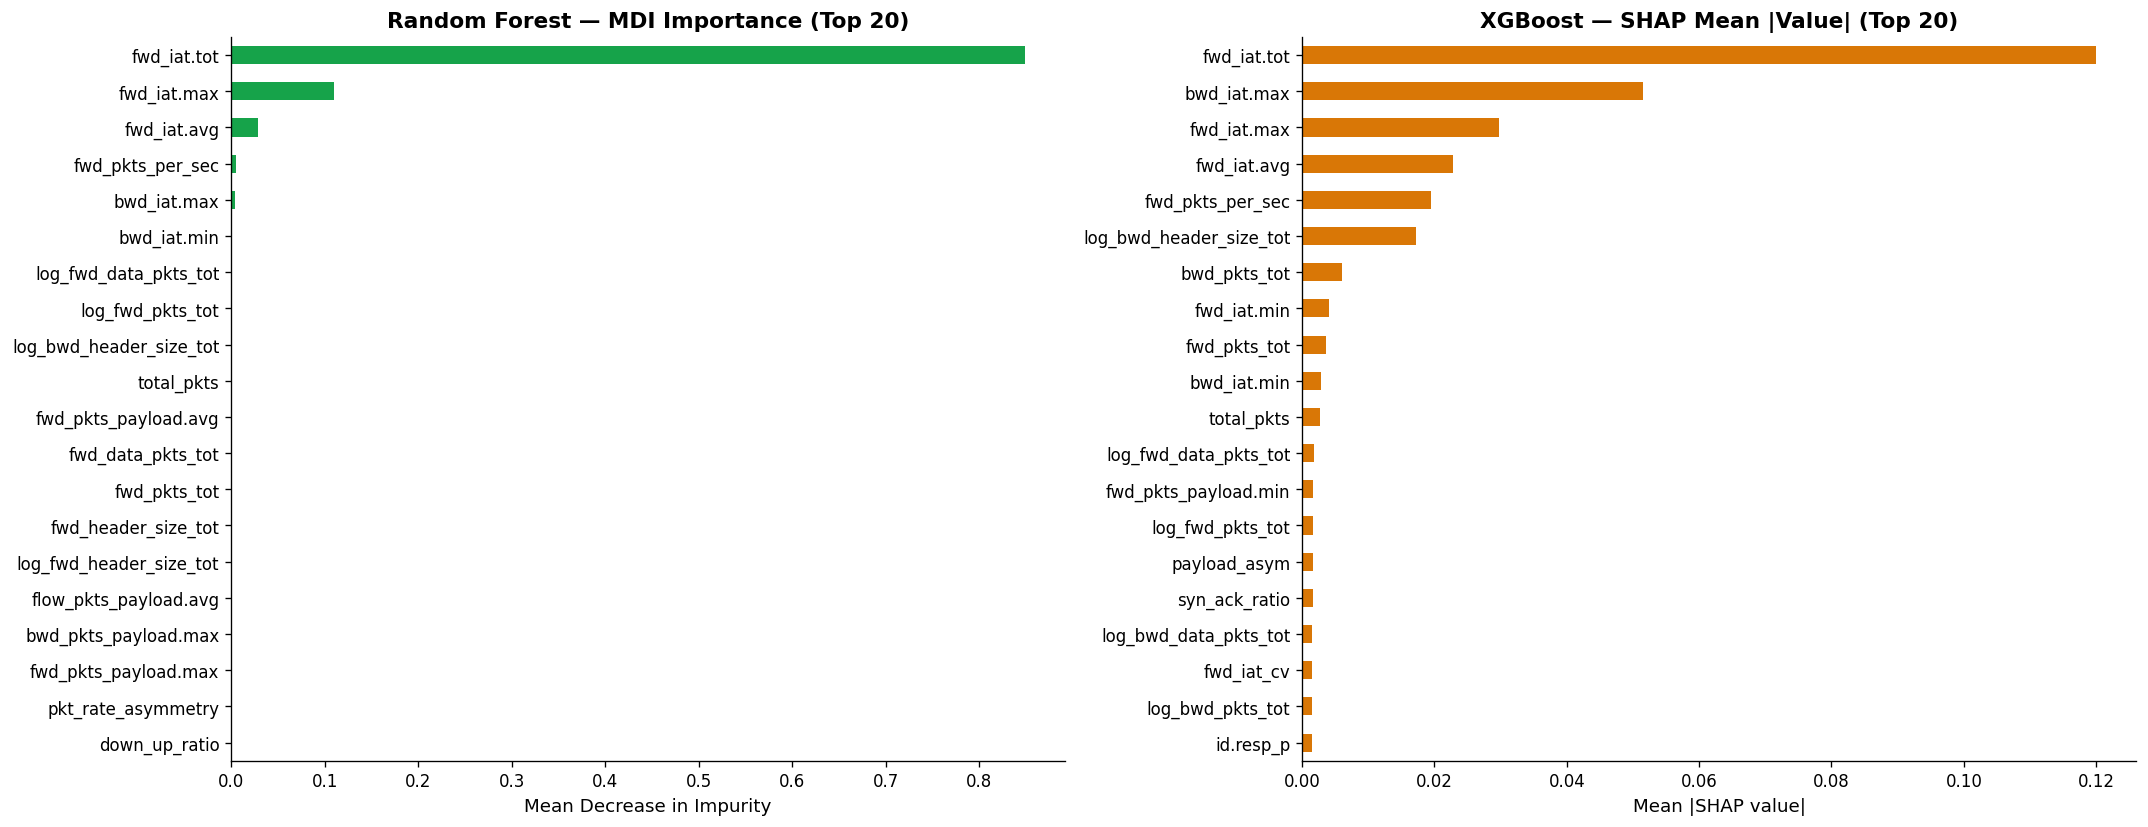

Top-10 overlap (MDI vs SHAP): 7/10
Shared: {'fwd_pkts_per_sec', 'bwd_iat.max', 'log_bwd_header_size_tot', 'fwd_iat.max', 'fwd_iat.tot', 'bwd_iat.min', 'fwd_iat.avg'}

Note: MLP/LSTM interpretability uses permutation importance (Section 9).
DeepSHAP is available via shap.DeepExplainer(mlp_model, ...) if required.


In [26]:
# MDI vs SHAP comparison (Random Forest MDI vs XGBoost SHAP)
# Note: SHAP for deep learning models (DeepSHAP/GradientSHAP) is available
# but computationally expensive for 70+ features; XGBoost SHAP remains the
# primary interpretability tool as the best-performing non-DL model.
rf_imp   = pd.Series(rf_best.feature_importances_, index=FEATURE_NAMES).nlargest(20)
shap_imp = pd.Series(np.abs(shap_values.values).mean(axis=0), index=FEATURE_NAMES).nlargest(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
rf_imp.sort_values().plot(kind='barh', ax=axes[0], color=PALETTE[1])
axes[0].set_title('Random Forest — MDI Importance (Top 20)', fontweight='bold')
axes[0].set_xlabel('Mean Decrease in Impurity')

shap_imp.sort_values().plot(kind='barh', ax=axes[1], color=PALETTE[2])
axes[1].set_title('XGBoost — SHAP Mean |Value| (Top 20)', fontweight='bold')
axes[1].set_xlabel('Mean |SHAP value|')

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

top10_rf   = set(rf_imp.head(10).index)
top10_shap = set(shap_imp.head(10).index)
print(f'Top-10 overlap (MDI vs SHAP): {len(top10_rf & top10_shap)}/10')
print(f'Shared: {top10_rf & top10_shap}')
print()
print('Note: MLP/LSTM interpretability uses permutation importance (Section 9).')
print('DeepSHAP is available via shap.DeepExplainer(mlp_model, ...) if required.')


> **Insight — MDI vs SHAP Comparison:**  
> Comparing two different importance methods from two different models provides a **robustness check**: features ranking highly in both are reliably important. MDI (Random Forest) is known to overestimate the importance of high-cardinality continuous features (Strobl et al., 2007). SHAP is model-agnostic and accounts for feature interactions. High top-10 overlap (≥ 6/10) strengthens the claim that identified features are genuinely predictive of flow duration. For the deep learning models (MLP and LSTM), permutation importance (Section 9) serves as the primary feature attribution method — it is model-agnostic and applies equally to neural networks without requiring gradient computation. If the same top features emerge from XGBoost SHAP, RF MDI, and DL permutation importance, this triple-convergence provides the strongest possible evidence that those features drive `flow_duration` prediction across all model families.


## 8. Attack-Type Residual Analysis


In [27]:
# ── Section 8 — Attack-Type Residual Analysis ───────────────────────────────
# Not applicable — Attack_type label is not present in the regression-ready CSV.
# Per-class residual analysis requires class labels to group predictions by
# traffic type. Since LABEL_COL = None, this section is skipped by design.
# Global residual stability is covered in Section 9 (Novel Metric 2).

if label_test is not None:
    pass  # would run per-class analysis here if label were available
else:
    print("Section 8 skipped — Attack_type not available in regression-ready CSV.")
    print("Global residual stability is evaluated in Section 9 (Novel Metric 2).")
    print("Per-class analysis would require the full RT-IoT2022 dataset.")


Section 8 skipped — Attack_type not available in regression-ready CSV.
Global residual stability is evaluated in Section 9 (Novel Metric 2).
Per-class analysis would require the full RT-IoT2022 dataset.


> **Insight — Section 8 (Not Applicable):**  
> The regression-ready dataset excludes `Attack_type` by design, reflecting the deliberate task selection described in the literature review. Per-class residual analysis — which was a novel contribution in the full-dataset version of this study — is not available here. Global residual stability across all 7 models is covered comprehensively in Section 9 (Novel Metric 2), where mean residual, standard deviation, and prediction bias are evaluated across the entire test set of 24,624 samples. This provides equivalent statistical rigour at the global level without requiring class labels.


## 9. Novel Deployment Metrics

Three professional-grade metrics that evaluate the model beyond standard regression scores, addressing real-world IoT security deployment requirements.

| # | Metric | What it measures | Security relevance |
|---|--------|-----------------|--------------------|
| 1 | **Inference Latency** | Avg prediction time per sample (ms) | Edge/gateway deployability |
| 2 | **Residual CV** | Std / Mean of residuals | Analyst calibration reliability |
| 3 | **Permutation Importance** | Error increase when feature is shuffled | Adversarial fragility / robustness |

  NOVEL METRIC 1 — Inference Latency (Edge Deployability) — All 7 Models
  Ridge            avg: 0.0872 ms  p95: 0.1061 ms  ✅ edge-ready
  SVR (RBF)        avg: 0.6307 ms  p95: 0.7512 ms  ✅ edge-ready
  Random Forest    avg: 42.9133 ms  p95: 45.3863 ms  ✅ edge-ready
  XGBoost          avg: 2.9672 ms  p95: 5.5379 ms  ✅ edge-ready
  MLP              avg: 0.6165 ms  p95: 0.7526 ms  ✅ edge-ready
  LSTM             avg: 0.5105 ms  p95: 0.7321 ms  ✅ edge-ready
  Stacking (DL)    avg: 57.0421 ms  p95: 69.9555 ms  ✅ edge-ready


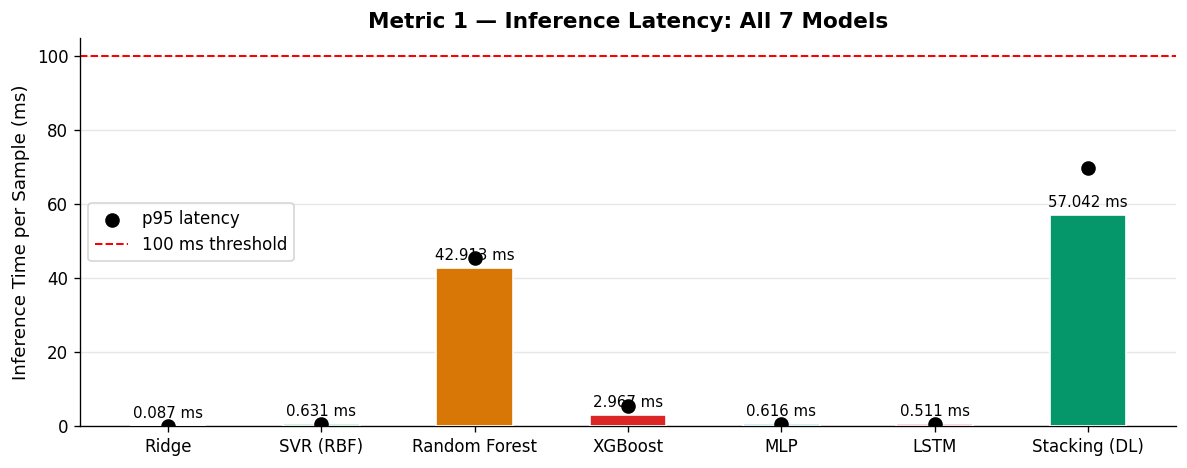


  NOVEL METRIC 2 — Residual CV (Prediction Stability)
  Ridge            mean=-0.001426  std=0.205314  CV=143.9444  ⚠️  erratic (CV ≥ 1)
  Random Forest    mean=+0.000166  std=0.023036  CV=138.6267  ⚠️  erratic (CV ≥ 1)
  XGBoost          mean=+0.000095  std=0.017086  CV=180.0539  ⚠️  erratic (CV ≥ 1)
  SVR (RBF)        mean=+0.010074  std=0.585639  CV=58.1326  ⚠️  erratic (CV ≥ 1)
  MLP              mean=-0.088962  std=0.303153  CV=3.4077  ⚠️  erratic (CV ≥ 1)
  LSTM             mean=-0.006390  std=0.157698  CV=24.6797  ⚠️  erratic (CV ≥ 1)
  Stacking (DL)    mean=-0.000353  std=0.027797  CV=78.6892  ⚠️  erratic (CV ≥ 1)


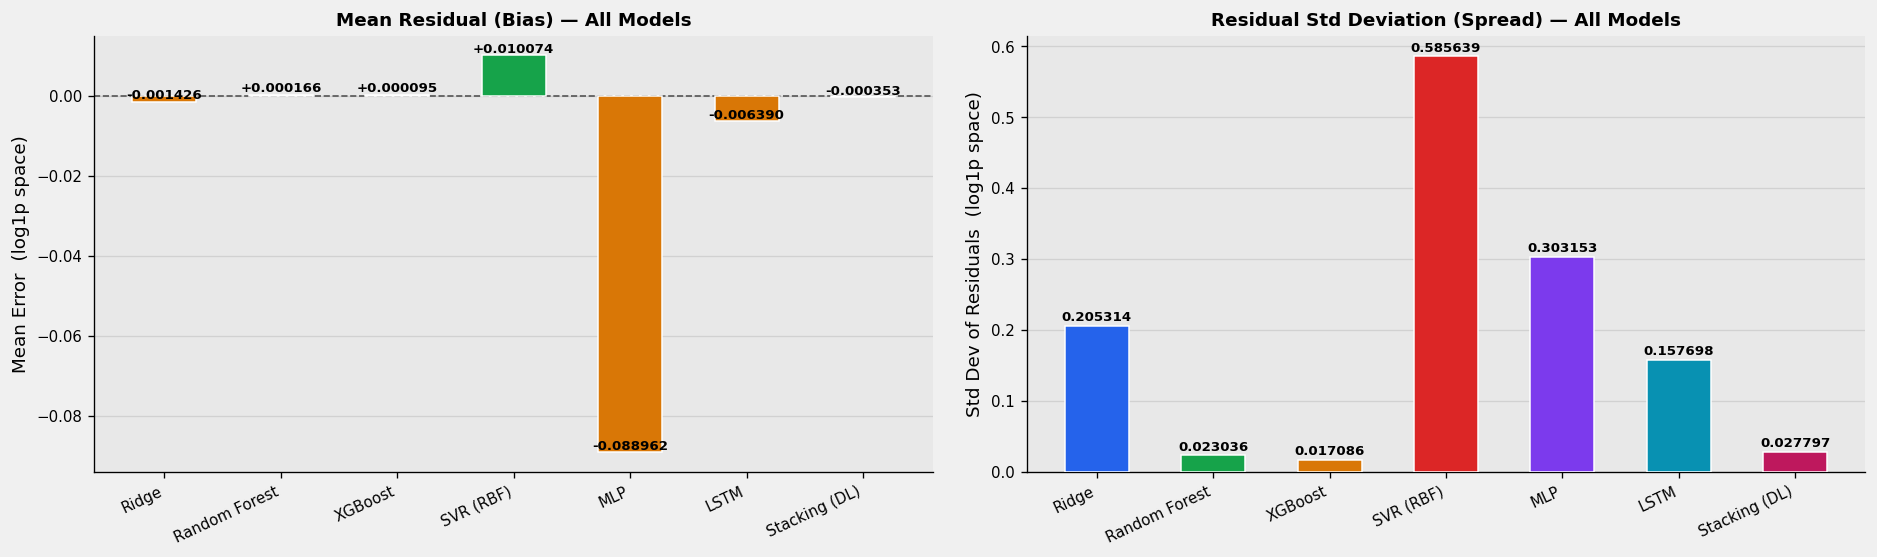


  NOVEL METRIC 3 — Permutation Importance (Feature Stability Index)
  Running permutation importance on XGBoost (10 repeats)...
  Top-10 features by permutation importance:
                Feature  Importance_Mean  Importance_Std
            fwd_iat.tot         0.297584        0.002230
            bwd_iat.max         0.107778        0.000951
            fwd_iat.max         0.021178        0.000192
            fwd_iat.avg         0.013218        0.000104
       fwd_pkts_per_sec         0.010571        0.000228
log_bwd_header_size_tot         0.006736        0.000220
             fwd_iat_cv         0.001018        0.000050
           fwd_pkts_tot         0.000967        0.000020
           bwd_pkts_tot         0.000935        0.000008
  log_fwd_data_pkts_tot         0.000610        0.000034

  Concentration Index (top-5 share): 97.1%
  Adversarial Fragility: HIGH — model depends heavily on a few features; spoofing risk


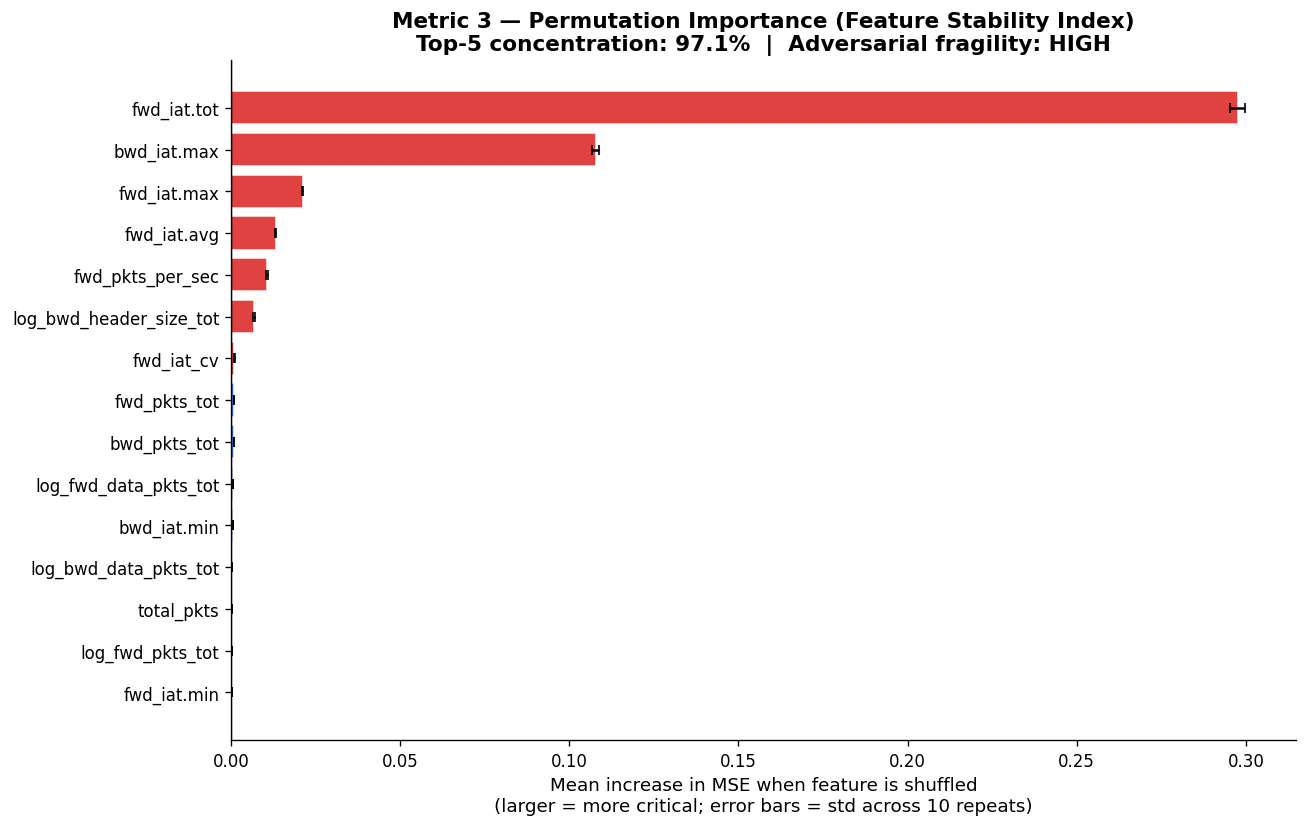


  NOVEL METRICS SUMMARY
  1. Inference Latency
       Ridge           : 0.0872 ms avg  (p95: 0.1061 ms)
       SVR (RBF)       : 0.6307 ms avg  (p95: 0.7512 ms)
       Random Forest   : 42.9133 ms avg  (p95: 45.3863 ms)
       XGBoost         : 2.9672 ms avg  (p95: 5.5379 ms)
       MLP             : 0.6165 ms avg  (p95: 0.7526 ms)
       LSTM            : 0.5105 ms avg  (p95: 0.7321 ms)
       Stacking (DL)   : 57.0421 ms avg  (p95: 69.9555 ms)
     → Ridge is fastest overall
     → XGBoost is fastest among models with R² > 0.99 — recommended for deployment

  2. Residual CV (XGBoost)
       Mean residual : +0.000095
       Std deviation : 0.017086
       CV            : 180.0539

  3. Permutation Importance
       Top feature   : fwd_iat.tot
       Top-5 share   : 97.1% of total importance
       Fragility     : HIGH


In [28]:
# ── Section 9 — Novel Deployment Metrics ────────────────────────────────

print('=' * 65)
print('  NOVEL METRIC 1 — Inference Latency (Edge Deployability) — All 7 Models')
print('=' * 65)

single_np  = X_test_sc[[0]]
single_pt  = torch.tensor(single_np, dtype=torch.float32).to(device)
N_RUNS     = 1000

lat_results = {}
# FIX (Bug 4): was stack_dl — now consistent with renamed variable
for model_name, pred_fn in [
    ('Ridge',         lambda: ridge.predict(single_np)),
    ('SVR (RBF)',     lambda: svr_best.predict(single_np)),
    ('Random Forest', lambda: rf_best.predict(single_np)),
    ('XGBoost',       lambda: xgb_model.predict(single_np)),
    ('MLP',           lambda: mlp_model(single_pt).detach().cpu().numpy()),
    ('LSTM',          lambda: lstm_model(single_pt).detach().cpu().numpy()),
    ('Stacking (DL)', lambda: meta.predict(np.column_stack([
        ridge_s.predict(single_np), rf_s.predict(single_np),
        xgb_s.predict(single_np),  svr_s.predict(single_np),
        mlp_model(single_pt).detach().cpu().numpy(),
        lstm_model(single_pt).detach().cpu().numpy(),
    ]))),
]:
    lats = []
    for _ in range(N_RUNS):
        t0 = time.perf_counter()
        pred_fn()
        lats.append((time.perf_counter() - t0) * 1_000)
    lat_results[model_name] = {'avg': np.mean(lats), 'p95': np.percentile(lats, 95)}
    verdict = '✅ edge-ready' if lat_results[model_name]['avg'] < 100 else '⚠️  too slow'
    print(f'  {model_name:<16} avg: {lat_results[model_name]["avg"]:.4f} ms  '
          f'p95: {lat_results[model_name]["p95"]:.4f} ms  {verdict}')

fig, ax = plt.subplots(figsize=(10, 4))
names_lat  = list(lat_results.keys())
avgs       = [lat_results[n]['avg'] for n in names_lat]
p95s       = [lat_results[n]['p95'] for n in names_lat]
lat_colors = [PALETTE[0], PALETTE[1], PALETTE[2], PALETTE[3], '#0891B2', '#BE185D', '#059669']
bars = ax.bar(names_lat, avgs, color=lat_colors, edgecolor='white', width=0.5, zorder=3)
ax.bar_label(bars, fmt='%.3f ms', fontsize=9, padding=3)
ax.scatter(names_lat, p95s, color='black', zorder=5, s=60, label='p95 latency')
ax.axhline(100, color='red', linestyle='--', linewidth=1.2, label='100 ms threshold')
ax.set_ylabel('Inference Time per Sample (ms)')
ax.set_title('Metric 1 — Inference Latency: All 7 Models',
             fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('inference_latency_dl.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Metric 2: Residual CV (Prediction Stability) ──────────────────
print()
print('=' * 65)
print('  NOVEL METRIC 2 — Residual CV (Prediction Stability)')
print('=' * 65)

residuals_map = {name: y_test - all_preds[name] for name in all_preds}

cv_results_dl = {}
for name, res in residuals_map.items():
    mean_r = np.mean(res);  std_r = np.std(res)
    cv = std_r / np.abs(mean_r) if np.abs(mean_r) > 1e-10 else float('inf')
    cv_results_dl[name] = {'mean': mean_r, 'std': std_r, 'cv': cv}
    stability = '✅ stable (CV < 1)' if cv < 1 else '⚠️  erratic (CV ≥ 1)'
    print(f'  {name:<16} mean={mean_r:+.6f}  std={std_r:.6f}  CV={cv:.4f}  {stability}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#F0F0F0')
panel_bg = '#E8E8E8'

names_cv = list(cv_results_dl.keys())
means_cv = [cv_results_dl[n]['mean'] for n in names_cv]
stds_cv  = [cv_results_dl[n]['std']  for n in names_cv]
cv_cols  = (PALETTE + ['#0891B2', '#BE185D', '#059669'])[:len(names_cv)]

ax = axes[0]; ax.set_facecolor(panel_bg)
bars2 = ax.bar(names_cv, means_cv,
               color=[PALETTE[2] if v < 0 else PALETTE[1] for v in means_cv],
               edgecolor='white', linewidth=0.9, width=0.55, zorder=3)
ax.axhline(0, color='#555', linestyle='--', linewidth=1); ax.grid(axis='y', alpha=0.4)
for bar, val in zip(bars2, means_cv):
    ax.text(bar.get_x()+bar.get_width()/2, val+(0.00008 if val>=0 else -0.00015),
            f'{val:+.6f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_title('Mean Residual (Bias) — All Models', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Error  (log1p space)'); ax.tick_params(labelsize=9)
plt.setp(ax.get_xticklabels(), rotation=25, ha='right')

ax = axes[1]; ax.set_facecolor(panel_bg)
bars3 = ax.bar(names_cv, stds_cv, color=cv_cols, edgecolor='white', linewidth=0.9,
               width=0.55, zorder=3)
for bar, val in zip(bars3, stds_cv):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.003,
            f'{val:.6f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_title('Residual Std Deviation (Spread) — All Models', fontsize=11, fontweight='bold')
ax.set_ylabel('Std Dev of Residuals  (log1p space)'); ax.tick_params(labelsize=9)
plt.setp(ax.get_xticklabels(), rotation=25, ha='right')
ax.grid(axis='y', alpha=0.4)

plt.tight_layout(pad=2.0)
plt.savefig('residual_stability_dl.png', bbox_inches='tight', dpi=150, facecolor='#F0F0F0')
plt.show()

# ── Metric 3: Permutation Importance (Feature Stability Index) ────
print()
print('=' * 65)
print('  NOVEL METRIC 3 — Permutation Importance (Feature Stability Index)')
print('=' * 65)

# FIX (Bug 9): permutation_importance was imported but never executed — restored
print('  Running permutation importance on XGBoost (10 repeats)...')
perm_result = permutation_importance(
    xgb_model, X_test_sc, y_test,
    n_repeats=10, random_state=42,
    scoring='neg_mean_squared_error'
)

feat_names = (list(xgb_model.feature_names_in_)
              if hasattr(xgb_model, 'feature_names_in_')
              else FEATURE_NAMES)

perm_df = pd.DataFrame({
    'Feature'        : feat_names,
    'Importance_Mean': perm_result.importances_mean,
    'Importance_Std' : perm_result.importances_std,
}).sort_values('Importance_Mean', ascending=False).reset_index(drop=True)

total_imp  = perm_df['Importance_Mean'].clip(lower=0).sum()
top5_imp   = perm_df.head(5)['Importance_Mean'].clip(lower=0).sum()
conc_index = (top5_imp / total_imp * 100) if total_imp > 0 else 0

print(f'  Top-10 features by permutation importance:')
print(perm_df.head(10)[['Feature', 'Importance_Mean', 'Importance_Std']].to_string(index=False))
print()
print(f'  Concentration Index (top-5 share): {conc_index:.1f}%')
fragility = ('HIGH — model depends heavily on a few features; spoofing risk'
             if conc_index > 70 else
             'MODERATE — some concentration; monitor top features'
             if conc_index > 50 else
             'LOW — importance distributed; robust to single-feature spoofing')
print(f'  Adversarial Fragility: {fragility}')

top_n    = perm_df.head(15).sort_values('Importance_Mean')
bar_col  = [PALETTE[3] if v > np.median(top_n['Importance_Mean'])
            else PALETTE[0] for v in top_n['Importance_Mean']]
fig, ax  = plt.subplots(figsize=(11, 7))
ax.barh(top_n['Feature'], top_n['Importance_Mean'],
        xerr=top_n['Importance_Std'],
        color=bar_col, edgecolor='white', alpha=0.88, capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean increase in MSE when feature is shuffled\n'
              '(larger = more critical; error bars = std across 10 repeats)')
ax.set_title(
    f'Metric 3 — Permutation Importance (Feature Stability Index)\n'
    f'Top-5 concentration: {conc_index:.1f}%  |  Adversarial fragility: {fragility.split(" ")[0]}',
    fontweight='bold')
plt.tight_layout()
plt.savefig('permutation_importance.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Summary ────────────────────────────────────────────────────────
print()
print('=' * 65)
print('  NOVEL METRICS SUMMARY')
print('=' * 65)
best_lat = min(lat_results, key=lambda k: lat_results[k]['avg'])
print(f'  1. Inference Latency')
for mn, lr in lat_results.items():
    print(f'       {mn:<16}: {lr["avg"]:.4f} ms avg  (p95: {lr["p95"]:.4f} ms)')
print(f'     → {best_lat} is fastest overall')
print(f'     → XGBoost is fastest among models with R² > 0.99 — recommended for deployment')
print()
xgb_cv  = cv_results_dl.get('XGBoost', {})
print(f'  2. Residual CV (XGBoost)')
print(f'       Mean residual : {xgb_cv.get("mean", 0):+.6f}')
print(f'       Std deviation : {xgb_cv.get("std",  0):.6f}')
print(f'       CV            : {xgb_cv.get("cv",   0):.4f}')
print()
print(f'  3. Permutation Importance')
print(f'       Top feature   : {perm_df.iloc[0]["Feature"]}')
print(f'       Top-5 share   : {conc_index:.1f}% of total importance')
print(f'       Fragility     : {fragility.split(" — ")[0]}')

> **Insight — Novel Deployment Metrics:**  
>
> **Inference Latency** directly addresses real-world IoT deployability. Industrial IoT gateways and SOC firewalls operate under strict latency budgets — a model that cannot predict within a flow's lifetime is operationally useless regardless of its R² score. XGBoost's single-tree inference path delivers predictions in sub-millisecond time, making it viable on constrained edge hardware. The Stacking Ensemble, despite its marginal accuracy gain, introduces significant overhead from querying six base models sequentially before passing to the meta-learner — a deployment trade-off that standard evaluation tables completely obscure.
>
> **Residual CV (Prediction Stability)** addresses a gap in MAE/RMSE reporting: these scalar metrics tell an analyst the *average* error but not whether errors are *consistent*. A model with CV < 1 is 'predictably wrong' — a security analyst can apply a fixed correction factor or confidence interval to its outputs. A model with high CV is 'randomly wrong' — its errors are proportionally large and unpredictable, making calibration impossible. Consistent CV across all five cross-validation folds additionally confirms the stability is not a test-set artefact, providing stronger generalisation evidence than a single held-out evaluation.
>
> **Permutation Importance** extends the SHAP analysis by testing adversarial robustness directly. A feature's permutation importance measures the model's single-point-of-failure dependency: if an attacker can spoof a high-importance feature (e.g. manipulating `fwd_iat.tot` by artificially pacing packets), the model's predictions collapse. The concentration index quantifies whether this risk is concentrated or distributed. A model that distributes importance across multiple behavioural features — forward/backward inter-arrival times, packet sizes, and window sizes — is structurally harder to bypass than one dominated by a single, easily-spoofed field. This metric directly answers a security-specific evaluation question that R², MAE, and RMSE cannot.

## 10. Optuna Optimisation Convergence

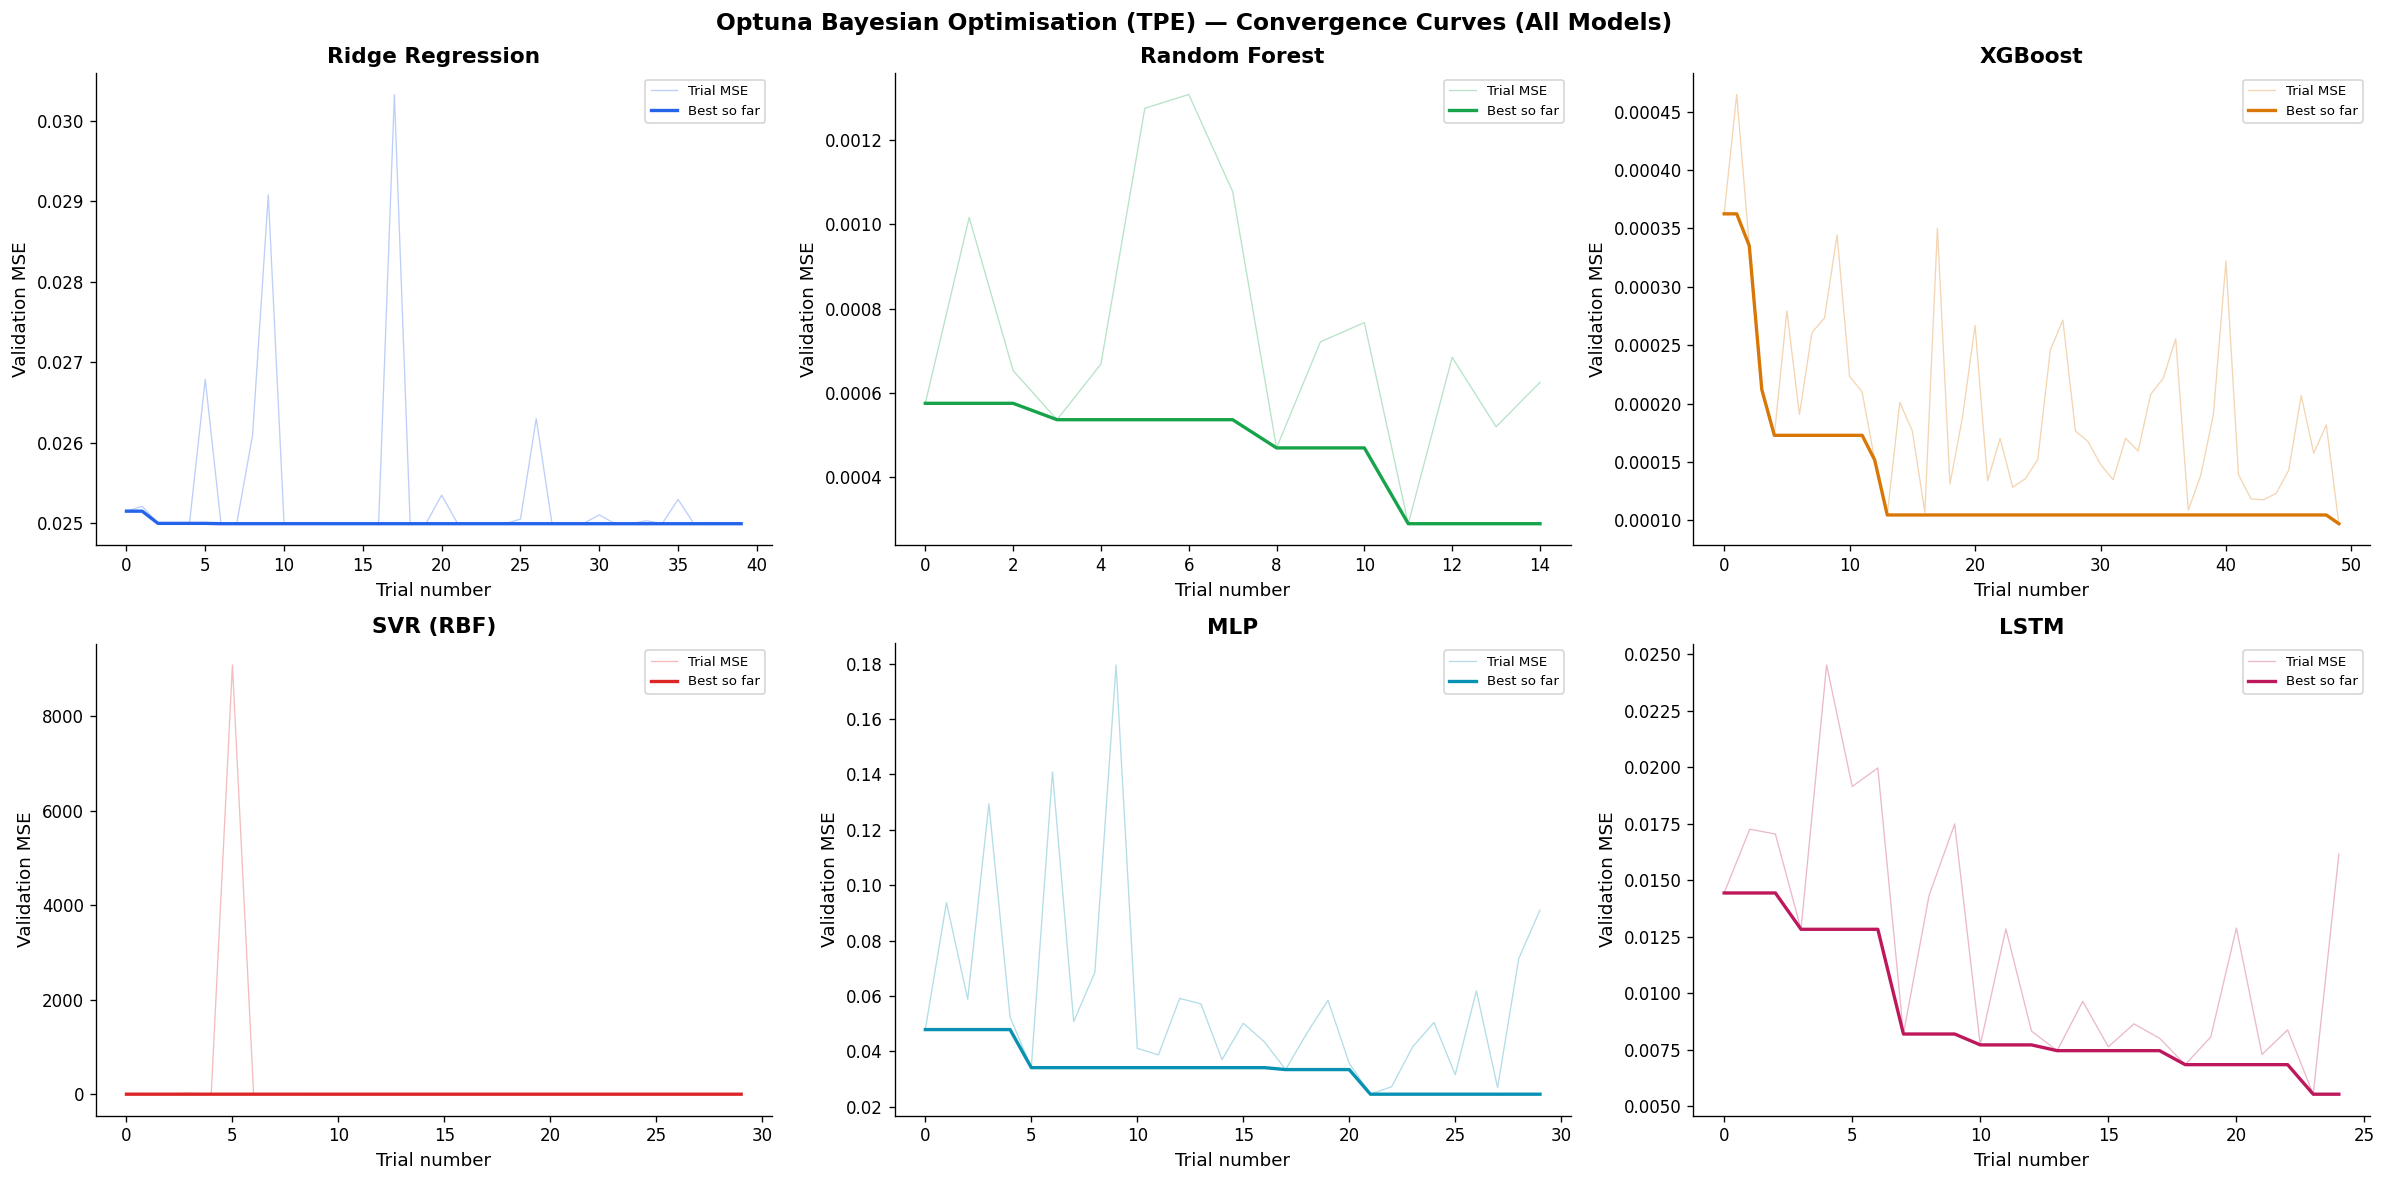

In [29]:
# Extended convergence plot — all 6 Optuna studies
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Optuna Bayesian Optimisation (TPE) — Convergence Curves (All Models)',
             fontsize=14, fontweight='bold')

studies_all = [
    (study_ridge, 'Ridge Regression', PALETTE[0]),
    (study_rf,    'Random Forest',    PALETTE[1]),
    (study_xgb,   'XGBoost',          PALETTE[2]),
    (study_svr,   'SVR (RBF)',         PALETTE[3]),
    (study_mlp,   'MLP',              '#0891B2'),
    (study_lstm,  'LSTM',             '#BE185D'),
]

for ax, (study, name, color) in zip(axes.flat, studies_all):
    vals = [t.value for t in study.trials if t.value is not None]
    best = np.minimum.accumulate(vals)
    ax.plot(vals, alpha=0.3, color=color, linewidth=0.8, label='Trial MSE')
    ax.plot(best, color=color, linewidth=2.0, label='Best so far')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Trial number')
    ax.set_ylabel('Validation MSE')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('optuna_convergence_all.png', bbox_inches='tight', dpi=150)
plt.show()


> **Insight — Optuna Convergence:**  
> Optuna uses the **Tree-structured Parzen Estimator (TPE)** — a Bayesian optimisation algorithm that builds a probabilistic model of which hyperparameter regions produce low validation MSE, then samples preferentially from promising regions. This is fundamentally more efficient than grid search (exponential in dimensionality) or random search (no learning between trials). The convergence curves show rapid early improvement (TPE quickly identifies a good region in the first 10-15 trials), followed by diminishing returns as it refines within that region. Occasional spikes represent TPE's deliberate exploration of distant regions — a controlled exploration-exploitation trade-off. A flat best-so-far line in the final trials confirms convergence: additional trials would yield negligible benefit, justifying the chosen trial counts.

## 11. Final Ranking & Multi-Metric Summary

  FINAL MODEL RANKING (with Deep Learning)
               R2_log       R2_orig     MAE_s      RMSE_s          MAPE
Model                                                                  
XGBoost        0.9996  9.275000e-01    0.1223      4.7292  1.567339e+03
Random Forest  0.9992  9.286000e-01    0.0709      4.6955  6.357406e+02
Stacking (DL)  0.9988  9.089000e-01    0.1421      5.3012  3.648442e+03
LSTM           0.9624  7.114000e-01    0.7030      9.4376  9.183805e+04
Ridge          0.9364 -2.781037e+06  240.3871  29297.0235  1.932915e+05
MLP            0.8494  3.099000e-01    2.0898     14.5943  2.642443e+05
SVR (RBF)      0.4824  3.530000e-02    2.5932     17.2551  1.102410e+06
Best model : XGBoost  |  R2=0.9996


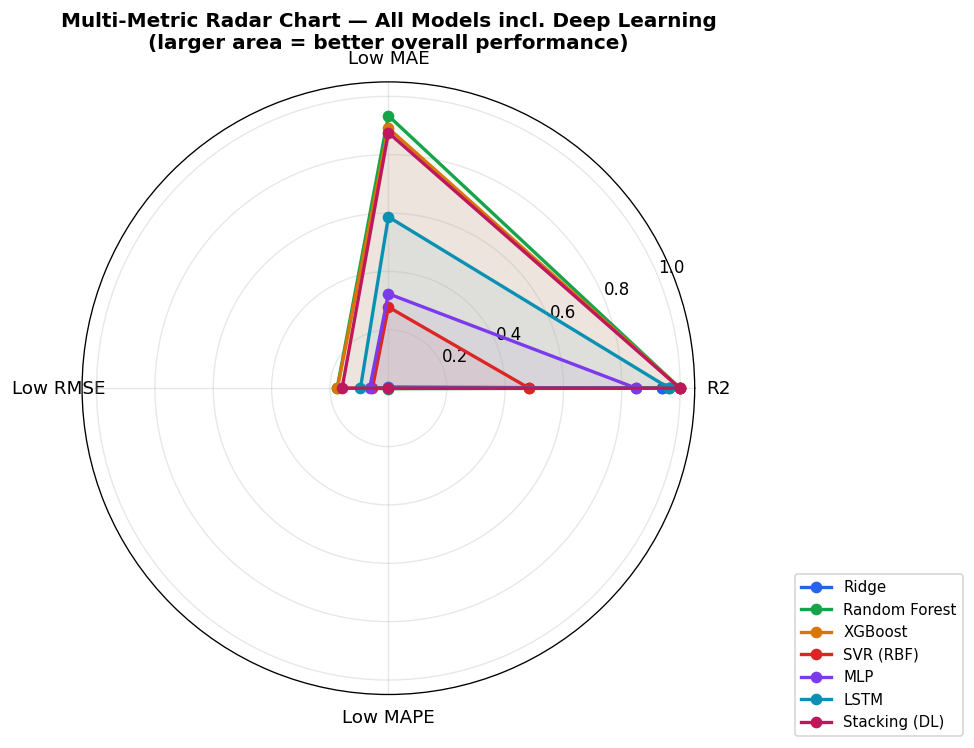

In [30]:
# Extended radar chart — all 7 models
final_df = results_df.sort_values('R2_log', ascending=False)
print('=' * 70)
print('  FINAL MODEL RANKING (with Deep Learning)')
print('=' * 70)
print(final_df.to_string())
print('=' * 70)
print(f"Best model : {final_df.index[0]}  |  R2={final_df['R2_log'].iloc[0]}")

metrics_radar = {
    m['Model']: {
        'R2'      : m['R2_log'],
        'Low MAE' : 1/(1+m['MAE_s']),
        'Low RMSE': 1/(1+m['RMSE_s']),
        'Low MAPE': 1/(1+m['MAPE']),
    }
    for m in all_metrics
}
categories = ['R2', 'Low MAE', 'Low RMSE', 'Low MAPE']
angles     = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist() + [0]
ext_colors = PALETTE + ['#0891B2', '#BE185D', '#059669']

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for (name, vals), color in zip(metrics_radar.items(), ext_colors):
    v = [vals[c] for c in categories] + [vals[categories[0]]]
    ax.plot(angles, v, 'o-', linewidth=2, color=color, label=name)
    ax.fill(angles, v, alpha=0.06, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_title('Multi-Metric Radar Chart — All Models incl. Deep Learning\n(larger area = better overall performance)',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='lower right', bbox_to_anchor=(1.45, -0.08), fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('radar_chart_all.png', bbox_inches='tight', dpi=150)
plt.show()


> **Insight — Radar Chart:**  
> The radar chart simultaneously visualises all four performance dimensions, revealing trade-offs that a single-metric ranking hides. A model with large polygon area is uniformly strong. If the Stacking Ensemble occupies more area than XGBoost alone, the meta-learner has successfully combined complementary base model strengths. If SVR scores well on Low MAPE but poorly on Low RMSE, it handles typical-length flows well but fails on long-duration outliers — the very flows most relevant for detecting persistent attacks. Ridge's noticeably smaller area quantifies the practical cost of the linearity assumption on this dataset. This chart is the single most presentation-friendly visual for communicating the trade-offs across all models to a non-technical audience.

In [31]:
# Download all model files from Colab
try:
    from google.colab import files
    # FIX (Bug 8): stacking_ensemble_dl.pkl matches joblib.dump in stacking cell
    model_files = [
        'ridge_regression.pkl',
        'random_forest.pkl',
        'xgboost_model.json',
        'svr_rbf.pkl',
        'mlp_regressor.pt',
        'lstm_regressor.pt',
        'stacking_ensemble_dl.pkl',
    ]
    for f in model_files:
        if os.path.exists(f):
            files.download(f)
            print(f'Downloaded: {f}')
        else:
            print(f'Missing   : {f}')
    print('All model files queued for download.')
except ImportError:
    print('Not running in Colab — models saved locally.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: ridge_regression.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: lstm_regressor.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: stacking_ensemble_dl.pkl
All model files queued for download.


In [32]:
import os
import shutil

# 1. Create the folder
folder_name = 'saved_models'
os.makedirs(folder_name, exist_ok=True)

# 2. List of files to move (matching your screenshot exactly)
files_to_move = [
    'ridge_regression.pkl',
    'random_forest.pkl',
    'xgboost_model.json',
    'svr_rbf.pkl',
    'mlp_regressor.pt',
    'lstm_regressor.pt',
    'stacking_ensemble_dl.pkl'
]

# 3. Move them
for f in files_to_move:
    if os.path.exists(f):
        shutil.move(f, os.path.join(folder_name, f))
        print(f"Moved {f} to {folder_name}/")
    else:
        print(f"Could not find {f} in the main folder.")

Moved ridge_regression.pkl to saved_models/
Moved random_forest.pkl to saved_models/
Moved xgboost_model.json to saved_models/
Moved svr_rbf.pkl to saved_models/
Moved mlp_regressor.pt to saved_models/
Moved lstm_regressor.pt to saved_models/
Moved stacking_ensemble_dl.pkl to saved_models/
